In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DATA.CSV

### Посмотрим на данные

In [2]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

file_ = '/content/drive/MyDrive/data.csv'



Mounted at /content/drive


In [3]:
data = pd.read_csv(file_)


In [4]:
data.shape

(545778, 49)

In [5]:
data.head(2)

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,...,distribution_center_geom,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,product_name_clean,customer_review
0,118730,94911,Shipped,F,2026-03-11 00:47:27+00:00,NaN,2026-03-12 20:06:27+00:00,NaN,1,2200,...,POINT(-89.9711 35.1174),172697,-92.088678,34.127955,Memphis TN,-89.9711,35.1174,False,Bella Two-Tone Full-Zip Hooded Sweatshirt,Just received the Bella Two-Tone Full-Zip Hood...
1,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaN,2026-03-13 23:10:02+00:00,NaN,2,21920,...,POINT(-95.3698 29.7604),167157,-119.645815,36.534992,Houston TX,-95.3698,29.7604,False,Calvin Klein Sportswear Men's Broken Micro Che...,I really liked this Calvin Klein Sportswear Me...


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545778 entries, 0 to 545777
Data columns (total 49 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        545778 non-null  int64  
 1   user_id                         545778 non-null  int64  
 2   status                          545778 non-null  object 
 3   gender                          545778 non-null  object 
 4   created_at                      545778 non-null  object 
 5   returned_at                     54174 non-null   object 
 6   shipped_at                      354054 non-null  object 
 7   delivered_at                    190125 non-null  object 
 8   num_of_item                     545778 non-null  int64  
 9   product_id                      545778 non-null  int64  
 10  inventory_item_id               545778 non-null  int64  
 11  sale_price                      545778 non-null  float64
 12  id              

In [7]:
data.columns

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item', 'product_id',
       'inventory_item_id', 'sale_price', 'id', 'first_name', 'last_name',
       'email', 'age', 'state', 'street_address', 'postal_code', 'city',
       'country', 'traffic_source', 'user_geom', 'cost', 'category', 'brand',
       'retail_price', 'department', 'sku', 'distribution_center_id',
       'sold_at', 'product_category', 'product_name', 'product_brand',
       'product_retail_price', 'product_department', 'product_sku',
       'product_distribution_center_id', 'distribution_center_geom',
       'order_item_id', 'delivery_longitude', 'delivery_latitude',
       'warehouse_name', 'warehouse_longitude', 'warehouse_latitude',
       'is_loyal', 'product_name_clean', 'customer_review'],
      dtype='object')



*   Поменять формат данных у created_at, returned_at , shipped_at, delivered_at - с object ---> date
*   Удалить столбец sold_at, так как во всех строках нет значений


*   Проверить столбцы с похожими названиями на полное совпадение (по типу brand --- product_brand)
*   Столбцы postal_code -- возможно тоже поменять формат


*   Удалить дублирующиеся строки







### Удалим дубликаты

In [8]:
data.duplicated().sum()

np.int64(363852)

In [9]:
data[data.duplicated(keep= False)].sort_values(by=list(data.columns)).head(5)

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,...,distribution_center_geom,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,product_name_clean,customer_review
95917,1,1,Complete,M,2024-10-14 10:31:40+00:00,NaN,2024-10-14 20:11:40+00:00,2024-10-19 07:17:40+00:00,1,22533,...,POINT(-118.25 34.05),1,-90.627780,41.588617,Los Angeles CA,-118.2500,34.05,False,KingSize Big & Tall Expandable Waist Wrinkle R...,Just received the KingSize Big & Tall Expandab...
277843,1,1,Complete,M,2024-10-14 10:31:40+00:00,NaN,2024-10-14 20:11:40+00:00,2024-10-19 07:17:40+00:00,1,22533,...,POINT(-118.25 34.05),1,-90.627780,41.588617,Los Angeles CA,-118.2500,34.05,False,KingSize Big & Tall Expandable Waist Wrinkle R...,Just received the KingSize Big & Tall Expandab...
459769,1,1,Complete,M,2024-10-14 10:31:40+00:00,NaN,2024-10-14 20:11:40+00:00,2024-10-19 07:17:40+00:00,1,22533,...,POINT(-118.25 34.05),1,-90.627780,41.588617,Los Angeles CA,-118.2500,34.05,False,KingSize Big & Tall Expandable Waist Wrinkle R...,Just received the KingSize Big & Tall Expandab...
73772,2,2,Complete,F,2025-04-11 13:43:06+00:00,NaN,2025-04-13 07:54:06+00:00,2025-04-16 08:37:06+00:00,2,12982,...,POINT(-90.0667 29.95),3,15.726955,51.221528,New Orleans LA,-90.0667,29.95,True,Lucky Brand My Tribe Banded Halter Top,"As a frequent shopper, I'm thrilled with this ..."
255698,2,2,Complete,F,2025-04-11 13:43:06+00:00,NaN,2025-04-13 07:54:06+00:00,2025-04-16 08:37:06+00:00,2,12982,...,POINT(-90.0667 29.95),3,15.726955,51.221528,New Orleans LA,-90.0667,29.95,True,Lucky Brand My Tribe Banded Halter Top,"As a frequent shopper, I'm thrilled with this ..."


In [10]:
data1 = data.drop_duplicates()
# оставит первое вхождение

In [11]:
data1.shape

(181926, 49)

In [12]:
data1.columns

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item', 'product_id',
       'inventory_item_id', 'sale_price', 'id', 'first_name', 'last_name',
       'email', 'age', 'state', 'street_address', 'postal_code', 'city',
       'country', 'traffic_source', 'user_geom', 'cost', 'category', 'brand',
       'retail_price', 'department', 'sku', 'distribution_center_id',
       'sold_at', 'product_category', 'product_name', 'product_brand',
       'product_retail_price', 'product_department', 'product_sku',
       'product_distribution_center_id', 'distribution_center_geom',
       'order_item_id', 'delivery_longitude', 'delivery_latitude',
       'warehouse_name', 'warehouse_longitude', 'warehouse_latitude',
       'is_loyal', 'product_name_clean', 'customer_review'],
      dtype='object')

### Проверим столбцы на схожесть

In [13]:
col = data1.columns
col
to_del = []

for i in range(len(col)):
  for j in range(i+1, len(col)):
    if data1[data1.columns[i]].equals(data1[data1.columns[j]]):
      print(f"{col[i]:<23} | {col[j]:<23}")
      to_del.append(col[j])

user_id                 | id                     
sale_price              | retail_price           
sale_price              | product_retail_price   
category                | product_category       
brand                   | product_brand          
retail_price            | product_retail_price   
department              | product_department     
sku                     | product_sku            
distribution_center_id  | product_distribution_center_id
product_name            | product_name_clean     


In [14]:
data1[['user_geom',	'delivery_longitude','delivery_latitude','distribution_center_geom','warehouse_longitude','warehouse_latitude']]

,user_geom,delivery_longitude,delivery_latitude,distribution_center_geom,warehouse_longitude,warehouse_latitude
0,POINT(-92.0886782 34.12795471),-92.088678,34.127955,POINT(-89.9711 35.1174),-89.9711,35.1174
1,POINT(-119.6458146 36.53499187),-119.645815,36.534992,POINT(-95.3698 29.7604),-95.3698,29.7604
2,POINT(-119.6458146 36.53499187),-119.645815,36.534992,POINT(-75.1667 39.95),-75.1667,39.9500
3,POINT(116.5019973 39.83631574),116.501997,39.836316,POINT(-87.6847 41.8369),-87.6847,41.8369
4,POINT(2.45549956 48.98550893),2.455500,48.985509,POINT(-118.25 34.05),-118.2500,34.0500
...,...,...,...,...,...,...
181921,POINT(-62.4853718 -7.362417987),-62.485372,-7.362418,POINT(-87.6847 41.8369),-87.6847,41.8369
181922,POINT(-62.4853718 -7.362417987),-62.485372,-7.362418,POINT(-88.0431 30.6944),-88.0431,30.6944
181923,POINT(-62.4853718 -7.362417987),-62.485372,-7.362418,POINT(-89.9711 35.1174),-89.9711,35.1174
181924,POINT(-62.4853718 -7.362417987),-62.485372,-7.362418,POINT(-95.3698 29.7604),-95.3698,29.7604


In [15]:
import re

def extract_coords(point_str):
    match = re.search(r'POINT\(([-\d.]+)\s+([-\d.]+)\)', point_str)
    if match:
        return float(match.group(1)), float(match.group(2))
    return None, None


data1['user_longitude'] = data1['user_geom'].apply(lambda x: extract_coords(x)[0])
data1['user_latitude'] = data1['user_geom'].apply(lambda x: extract_coords(x)[1])

longitude_match = data1['user_longitude'] == data1['delivery_longitude']
latitude_match = data1['user_latitude'] == data1['delivery_latitude']

coords_match = longitude_match & latitude_match #булевы

print(f"Совпадающих координат: {coords_match.sum()}")
print(f"Не совпадающих: {(~coords_match).sum()}")

data1 = data1.drop(columns= ['user_longitude', 'user_latitude'])

/tmp/ipykernel_14267/2005638555.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['user_longitude'] = data1['user_geom'].apply(lambda x: extract_coords(x)[0])


Совпадающих координат: 181926
Не совпадающих: 0


/tmp/ipykernel_14267/2005638555.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['user_latitude'] = data1['user_geom'].apply(lambda x: extract_coords(x)[1])


In [16]:
def extract_coords_dist(point_str):
    match = re.search(r'POINT\(([-\d.]+)\s+([-\d.]+)\)', point_str)
    if match:
        return float(match.group(1)), float(match.group(2))
    return None, None


data1['dist_longitude'] = data1['distribution_center_geom'].apply(lambda x: extract_coords(x)[0])
data1['dist_latitude'] = data1['distribution_center_geom'].apply(lambda x: extract_coords(x)[1])

longitude_match = data1['dist_longitude'] == data1['warehouse_longitude']
latitude_match = data1['dist_latitude'] == data1['warehouse_latitude']

coords_match = longitude_match & latitude_match

print(f"Совпадающих координат: {coords_match.sum()}")
print(f"Не совпадающих: {(~coords_match).sum()}")

data1 = data1.drop(columns= ['dist_longitude', 'dist_latitude'])

Совпадающих координат: 181926
Не совпадающих: 0


In [17]:
to_del.append('distribution_center_geom')
to_del.append('user_geom')

data_clean = data1.drop(columns= to_del)

In [18]:
to_del

['id',
 'retail_price',
 'product_retail_price',
 'product_category',
 'product_brand',
 'product_retail_price',
 'product_department',
 'product_sku',
 'product_distribution_center_id',
 'product_name_clean',
 'distribution_center_geom',
 'user_geom']

In [19]:
data_clean.shape

(181926, 38)

In [20]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181926 entries, 0 to 181925
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                181926 non-null  int64  
 1   user_id                 181926 non-null  int64  
 2   status                  181926 non-null  object 
 3   gender                  181926 non-null  object 
 4   created_at              181926 non-null  object 
 5   returned_at             18058 non-null   object 
 6   shipped_at              118018 non-null  object 
 7   delivered_at            63375 non-null   object 
 8   num_of_item             181926 non-null  int64  
 9   product_id              181926 non-null  int64  
 10  inventory_item_id       181926 non-null  int64  
 11  sale_price              181926 non-null  float64
 12  first_name              181926 non-null  object 
 13  last_name               181926 non-null  object 
 14  email                   1

### Изменим формат некоторых данных

In [21]:
data_clean

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,...,sold_at,product_name,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,customer_review
0,118730,94911,Shipped,F,2026-03-11 00:47:27+00:00,NaN,2026-03-12 20:06:27+00:00,NaN,1,2200,...,NaN,Bella Two-Tone Full-Zip Hooded Sweatshirt,172697,-92.088678,34.127955,Memphis TN,-89.9711,35.1174,False,Just received the Bella Two-Tone Full-Zip Hood...
1,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaN,2026-03-13 23:10:02+00:00,NaN,2,21920,...,NaN,Calvin Klein Sportswear Men's Broken Micro Che...,167157,-119.645815,36.534992,Houston TX,-95.3698,29.7604,False,I really liked this Calvin Klein Sportswear Me...
2,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaN,2026-03-13 23:10:02+00:00,NaN,2,20031,...,NaN,FactoryExtreme Neptune Men's Black Biker Leath...,167158,-119.645815,36.534992,Philadelphia PA,-75.1667,39.9500,False,Nice FactoryExtreme Neptune Men's Black Biker ...
3,99949,79993,Complete,F,2026-03-11 00:39:44.268552+00:00,NaN,2026-03-13 17:24:44.268552+00:00,2026-03-16 01:00:44.268552+00:00,1,15500,...,NaN,HUE Women's 3-Pack Hidden Cotton Liner,145310,116.501997,39.836316,Chicago IL,-87.6847,41.8369,False,Nice HUE Women's 3-Pack Hidden Cotton Liner. W...
4,92967,74352,Shipped,M,2026-03-11 00:39:29.765939+00:00,NaN,2026-03-12 11:30:29.765939+00:00,NaN,1,18572,...,NaN,Zorrel - Insect Shield Apparel Long Sleeve Tee...,135249,2.455500,48.985509,Los Angeles CA,-118.2500,34.0500,False,Good value for money. The Zorrel - Insect Shie...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181921,32199,25808,Shipped,F,2019-01-10 19:40:10+00:00,NaN,2019-01-13 00:21:10+00:00,NaN,4,10095,...,NaN,Midnight By Carole Hochman Women's Swept Away ...,46856,-62.485372,-7.362418,Chicago IL,-87.6847,41.8369,True,"As a frequent shopper, I'm thrilled with this ..."
181922,32199,25808,Shipped,F,2019-01-10 19:40:10+00:00,NaN,2019-01-13 00:21:10+00:00,NaN,4,1836,...,NaN,American Apparel Unisex Dolman Sleeve Hoodie,46858,-62.485372,-7.362418,Mobile AL,-88.0431,30.6944,True,Another 5-star purchase! This American Apparel...
181923,32199,25808,Shipped,F,2019-01-10 19:40:10+00:00,NaN,2019-01-13 00:21:10+00:00,NaN,4,14985,...,NaN,Adjustable Bra Design Front Panel Clasp Matern...,46855,-62.485372,-7.362418,Memphis TN,-89.9711,35.1174,True,"I always order my gear here, and this Adjustab..."
181924,32199,25808,Shipped,F,2019-01-10 19:40:10+00:00,NaN,2019-01-13 00:21:10+00:00,NaN,4,7231,...,NaN,Jones New York Women's Boot Skirt,46857,-62.485372,-7.362418,Houston TX,-95.3698,29.7604,True,Best brand ever. This Jones New York Women's B...


In [22]:
data_clean['created_at'] = pd.to_datetime(data_clean['created_at'], format='ISO8601')
data_clean['returned_at'] = pd.to_datetime(data_clean['returned_at'], format='ISO8601')
data_clean['shipped_at'] = pd.to_datetime(data_clean['shipped_at'], format='ISO8601')
data_clean['delivered_at'] = pd.to_datetime(data_clean['delivered_at'], format='ISO8601')

In [23]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181926 entries, 0 to 181925
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   order_id                181926 non-null  int64              
 1   user_id                 181926 non-null  int64              
 2   status                  181926 non-null  object             
 3   gender                  181926 non-null  object             
 4   created_at              181926 non-null  datetime64[ns, UTC]
 5   returned_at             18058 non-null   datetime64[ns, UTC]
 6   shipped_at              118018 non-null  datetime64[ns, UTC]
 7   delivered_at            63375 non-null   datetime64[ns, UTC]
 8   num_of_item             181926 non-null  int64              
 9   product_id              181926 non-null  int64              
 10  inventory_item_id       181926 non-null  int64              
 11  sale_price              181926 

### Поработаем с null

In [24]:
data_clean.isna().sum()[data_clean.isna().sum()>0].sort_values(ascending= False)

,0
sold_at,181926
returned_at,163868
delivered_at,118551
shipped_at,63908
city,1818
brand,184
product_name,7


In [25]:
data_clean =data_clean.drop(columns = 'sold_at')

In [26]:
data_clean.columns

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item', 'product_id',
       'inventory_item_id', 'sale_price', 'first_name', 'last_name', 'email',
       'age', 'state', 'street_address', 'postal_code', 'city', 'country',
       'traffic_source', 'cost', 'category', 'brand', 'department', 'sku',
       'distribution_center_id', 'product_name', 'order_item_id',
       'delivery_longitude', 'delivery_latitude', 'warehouse_name',
       'warehouse_longitude', 'warehouse_latitude', 'is_loyal',
       'customer_review'],
      dtype='object')

In [27]:
len(data_clean.columns)

37

In [28]:
data_clean.shape

(181926, 37)

дозаполнить пробелы в city не получится , так как нет вообще никакой информации у тех user_id о городе

по пропущенным product_name аналогично

### Итого столбцы

In [29]:
description = pd.DataFrame({
    'Name' : data_clean.columns,
    'Desc' : ['Уникальный номер заказа', 'Уникальный айди покупателя', 'Статус заказа', "Пол покупателя", "Дата создания заказа", "Дата возврата заказа", "Дата отправки заказа", "Дата доставки заказа",
              "Количество товаров (?)", "Айди товара", "inventory_item_id (?)", "Цена со скидкой", "Имя", "Фамилия", "Почта", "возраст", "Штат", "Адрес покупателя", "Почтовый индекс",
              "Город", "Страна", "traffic_source (?)", "Цена", "Категория товара", "Брэнд товара",  "department", "sku", "Айдишник распределительного центра", "Наименование товара",
              "order_item_id (?)", "Координата долготы юзера", "Координата широты юзера", "Название склада", "Координата долготы warehouse","Координата долготы warehouse",
              "Лоялен?", "Отзыв"
              ]
}
)

description

,Name,Desc
0,order_id,Уникальный номер заказа
1,user_id,Уникальный айди покупателя
2,status,Статус заказа
3,gender,Пол покупателя
4,created_at,Дата создания заказа
5,returned_at,Дата возврата заказа
6,shipped_at,Дата отправки заказа
7,delivered_at,Дата доставки заказа
8,num_of_item,Количество товаров (?)
9,product_id,Айди товара


### Анализ данных

In [30]:
data_clean['gender'].value_counts(normalize=True)

,proportion
gender,
M,0.501726
F,0.498274


In [31]:
data_clean['status'].value_counts(normalize=True)

,proportion
status,
Shipped,0.300358
Complete,0.249096
Processing,0.199235
Cancelled,0.152051
Returned,0.099260


In [32]:
data_clean['is_loyal'].value_counts(normalize=True)

,proportion
is_loyal,
False,0.570413
True,0.429587


In [33]:
def abc_analysis(df, value_column, group_column='user_id',
                 group_name='Клиенты', show_plot=True):

    grouped = df.groupby(group_column)[value_column].sum().reset_index()
    grouped.columns = [group_column, 'total_value']

    grouped = grouped.sort_values('total_value', ascending=False).reset_index(drop=True)
    grouped['cumulative_sum'] = grouped['total_value'].cumsum()
    grouped['cumulative_percent'] = (grouped['cumulative_sum'] / grouped['total_value'].sum()) * 100

    conditions = [
        grouped['cumulative_percent'] <= 20,
        (grouped['cumulative_percent'] > 20) & (grouped['cumulative_percent'] <= 50),
        grouped['cumulative_percent'] > 50
    ]
    choices = ['A', 'B', 'C']
    grouped['category ABC'] = np.select(conditions, choices, default='C')

    total_items = len(grouped)
    grouped['count_percent'] = (grouped.index + 1) / total_items * 100

    category_stats = grouped.groupby('category ABC').agg({
        group_column: 'count',
        'total_value': 'sum'
    }).rename(columns={group_column: 'count', 'total_value': 'total_value'})

    category_stats['value_percent'] = (category_stats['total_value'] / category_stats['total_value'].sum() * 100).round(2)
    category_stats['count_percent'] = (category_stats['count'] / category_stats['count'].sum() * 100).round(2)

    print(f"\n{'='*60}")
    print(f"ABC-АНАЛИЗ: {group_name} по показателю '{value_column}'")
    print(f"{'='*60}")
    print(category_stats)

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax1 = axes[0]
        ax1.bar(range(len(grouped)), grouped['total_value'], alpha=0.6, label='Значение')
        ax1.set_xlabel(f'{group_name}', fontsize=12)
        ax1.set_ylabel(f'{value_column}', fontsize=12)
        ax1.set_title(f'ABC-анализ {group_name} по {value_column}', fontsize=14)

        ax1_twin = ax1.twinx()
        ax1_twin.plot(range(len(grouped)), grouped['cumulative_percent'],
                      color='red', marker='o', linewidth=2, label='Накопленный %')
        ax1_twin.axhline(y=20, color='green', linestyle='--', alpha=0.7, label='20% граница')
        ax1_twin.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='50% граница')
        ax1_twin.set_ylabel('Накопленный процент (%)', fontsize=12)
        ax1_twin.set_ylim(0, 105)

        ax1.axvspan(0, category_stats.loc['A', 'count']-1, alpha=0.2, color='green', label='A')
        ax1.axvspan(category_stats.loc['A', 'count']-1,
                    category_stats.loc['A', 'count'] + category_stats.loc['B', 'count']-1,
                    alpha=0.2, color='yellow', label='B')
        ax1.axvspan(category_stats.loc['A', 'count'] + category_stats.loc['B', 'count']-1,
                    len(grouped)-1, alpha=0.2, color='red', label='C')

        ax1.legend(loc='upper left')
        ax1_twin.legend(loc='upper right')

        ax2 = axes[1]
        colors = {'A': '#2ecc71', 'B': '#f39c12', 'C': '#e74c3c'}
        wedges, texts, autotexts = ax2.pie(
            category_stats['total_value'],
            labels=[f"{cat}\n{val:.1f}%" for cat, val in category_stats['value_percent'].items()],
            autopct='%1.1f%%',
            colors=[colors[cat] for cat in category_stats.index],
            startangle=90,
            explode=(0.05, 0.05, 0.05)
        )
        ax2.set_title(f'Доля {value_column} по категориям', fontsize=14)

        plt.tight_layout()
        plt.show()

    return grouped, category_stats


ABC-АНАЛИЗ: Клиенты по показателю 'sale_price'
              count   total_value  value_percent  count_percent
category ABC                                                   
A              3796  2.164451e+06           20.0           4.74
B             10973  3.246884e+06           30.0          13.71
C             65252  5.411774e+06           50.0          81.54


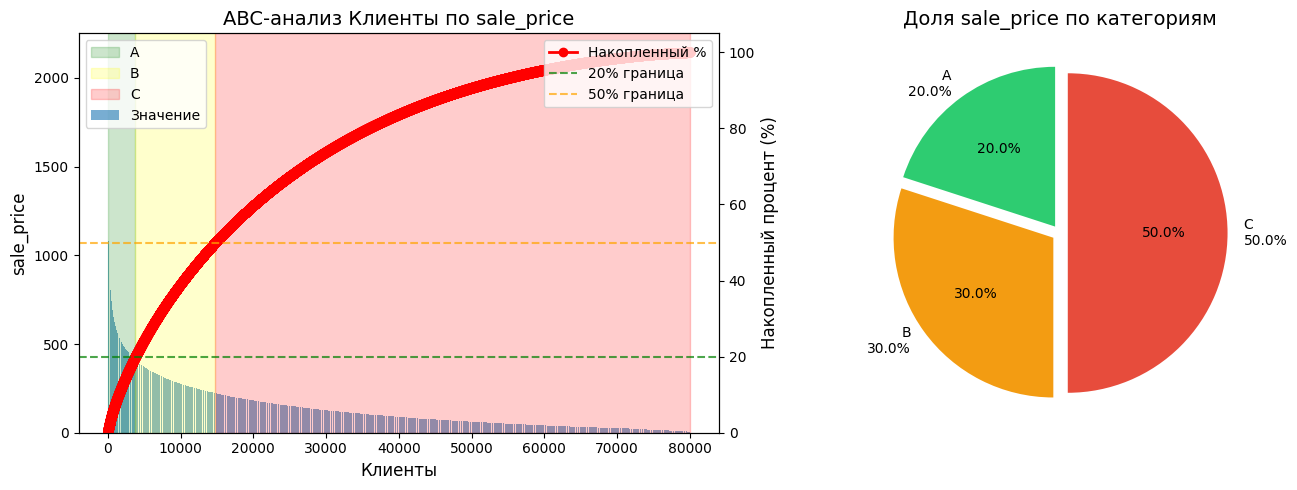


Топ-10 клиентов категории A:


In [34]:
# ABC-анализ клиентов по выручке
abc_revenue, revenue_stats = abc_analysis(
    data_clean,
    value_column='sale_price',
    group_column='user_id',
    group_name='Клиенты'
)

print("\nТоп-10 клиентов категории A:")

А— наиболее ценные

В— промежуточные

С— наименее ценные

Обычно 20% клиентов дают 80% выручки. У нас 4.74% + 13.71% = 18.45% клиентов дают 50% выручки. Бизнес менее зависим от топ-клиентов. Это хорошо с точки зрения устойчивости, но может указывать на:



1.   Низкую лояльность клиентов
2.   Отсутствие крупных корпоративных клиентов
3.   Товары/услуги массового спроса с низким чеком



Средний чек A: 570 руб   (2_164_451 / 3_796)

Средний чек B: 296 руб   (3_246_884 / 10_973)

Средний чек C: 83 руб    (5_411_774 / 65_252 )

Средний чек общий: 135 руб  (10_823_109 / 80_021)

Клиент из A приносит в 6.9 раз больше, чем из C.

Средний чек категории С ниже, чем общий средний чек. (в 1.6 раза). 50% выручки приносят убыточные клиенты


Рекомендации:

Внедрить программу лояльности для удержания клиентов А (сейчас is_loyal лишь 43%)

Ввести акции и промокоды для повышения среднего чека клиенов В.

Посмотреть на затраты на привлечение клиентов(?).






In [35]:
data_analys = data_clean.copy()
data_analys['created_at'] = pd.to_datetime(data_analys['created_at'])
data_analys['year created'] = data_analys['created_at'].dt.year
data_analys['month created'] = data_analys['created_at'].dt.month
data_analys['quarter'] = data_analys['created_at'].dt.quarter
# data_analys['day_of_week'] = data_analys['created_at'].dt.dayofweek  # 0=пн, 6=вс

data_analys['profit'] = data_analys['sale_price'] - data_analys['cost']
data_analys['margin_percent'] = (data_analys['profit'] / data_analys['sale_price'] * 100).fillna(0)


In [36]:
data_analys.columns

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item', 'product_id',
       'inventory_item_id', 'sale_price', 'first_name', 'last_name', 'email',
       'age', 'state', 'street_address', 'postal_code', 'city', 'country',
       'traffic_source', 'cost', 'category', 'brand', 'department', 'sku',
       'distribution_center_id', 'product_name', 'order_item_id',
       'delivery_longitude', 'delivery_latitude', 'warehouse_name',
       'warehouse_longitude', 'warehouse_latitude', 'is_loyal',
       'customer_review', 'year created', 'month created', 'quarter', 'profit',
       'margin_percent'],
      dtype='object')

In [38]:
data_analys

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,...,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,customer_review,year created,month created,quarter,profit,margin_percent
0,118730,94911,Shipped,F,2026-03-11 00:47:27+00:00,NaT,2026-03-12 20:06:27+00:00,NaT,1,2200,...,Memphis TN,-89.9711,35.1174,False,Just received the Bella Two-Tone Full-Zip Hood...,2026,3,1,16.659951,50.5
1,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaT,2026-03-13 23:10:02+00:00,NaT,2,21920,...,Houston TX,-95.3698,29.7604,False,I really liked this Calvin Klein Sportswear Me...,2026,3,1,19.745430,49.9
2,114939,91961,Shipped,M,2026-03-11 00:46:02+00:00,NaT,2026-03-13 23:10:02+00:00,NaT,2,20031,...,Philadelphia PA,-75.1667,39.9500,False,Nice FactoryExtreme Neptune Men's Black Biker ...,2026,3,1,125.862658,56.7
3,99949,79993,Complete,F,2026-03-11 00:39:44.268552+00:00,NaT,2026-03-13 17:24:44.268552+00:00,2026-03-16 01:00:44.268552+00:00,1,15500,...,Chicago IL,-87.6847,41.8369,False,Nice HUE Women's 3-Pack Hidden Cotton Liner. W...,2026,3,1,11.250000,45.0
4,92967,74352,Shipped,M,2026-03-11 00:39:29.765939+00:00,NaT,2026-03-12 11:30:29.765939+00:00,NaT,1,18572,...,Los Angeles CA,-118.2500,34.0500,False,Good value for money. The Zorrel - Insect Shie...,2026,3,1,13.600000,54.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181921,32199,25808,Shipped,F,2019-01-10 19:40:10+00:00,NaT,2019-01-13 00:21:10+00:00,NaT,4,10095,...,Chicago IL,-87.6847,41.8369,True,"As a frequent shopper, I'm thrilled with this ...",2019,1,1,9.900000,39.6
181922,32199,25808,Shipped,F,2019-01-10 19:40:10+00:00,NaT,2019-01-13 00:21:10+00:00,NaT,4,1836,...,Mobile AL,-88.0431,30.6944,True,Another 5-star purchase! This American Apparel...,2019,1,1,14.703000,50.7
181923,32199,25808,Shipped,F,2019-01-10 19:40:10+00:00,NaT,2019-01-13 00:21:10+00:00,NaT,4,14985,...,Memphis TN,-89.9711,35.1174,True,"I always order my gear here, and this Adjustab...",2019,1,1,15.444850,51.5
181924,32199,25808,Shipped,F,2019-01-10 19:40:10+00:00,NaT,2019-01-13 00:21:10+00:00,NaT,4,7231,...,Houston TX,-95.3698,29.7604,True,Best brand ever. This Jones New York Women's B...,2019,1,1,36.638609,61.9


In [ ]:
# import pandas as pd
# from google.colab import files

# # Создаем копию
# data_analys_clean = data_analys.copy()

# # Находим все столбцы с datetime (исправленная версия)
# datetime_cols = data_analys_clean.select_dtypes(include=['datetime64', 'datetimetz']).columns

# print(f"Столбцы с datetime: {list(datetime_cols)}")

# # Удаляем часовой пояс из datetime столбцов
# for col in datetime_cols:
#     if data_analys_clean[col].dt.tz is not None:
#         data_analys_clean[col] = data_analys_clean[col].dt.tz_localize(None)

# # Сохраняем в Excel
# data_analys_clean.to_excel('data_analys.xlsx', index=False, engine='openpyxl')

# # Скачиваем
# files.download('data_analys.xlsx')

# print("✅ Файл успешно сохранен")

Столбцы с datetime: ['created_at', 'returned_at', 'shipped_at', 'delivered_at']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Файл успешно сохранен


In [39]:
data_analys['year created'].value_counts()

,count
year created,
2025,60309
2024,35996
2026,26372
2023,24526
2022,16362
2021,10753
2020,5753
2019,1855



ABC-АНАЛИЗ: Клиенты по показателю 'sale_price'
              count   total_value  value_percent  count_percent
category ABC                                                   
A              3796  2.164451e+06           20.0           4.74
B             10973  3.246884e+06           30.0          13.71
C             65252  5.411774e+06           50.0          81.54
АНАЛИЗ ПРИБЫЛЬНОСТИ ПО КАТЕГОРИЯМ ABC
              order_count  sale_price      profit        cost  margin_percent  \
category ABC                                                                    
A                   20283  2164451.24  1153172.29  1011278.95           51.61   
B                   43808  3246883.87  1692640.49  1554243.38           51.22   
C                  117835  5411773.72  2770268.00  2641505.72           50.87   

              profit_per_order  revenue_per_order  cost_per_order  
category ABC                                                       
A                        56.85             106.71   

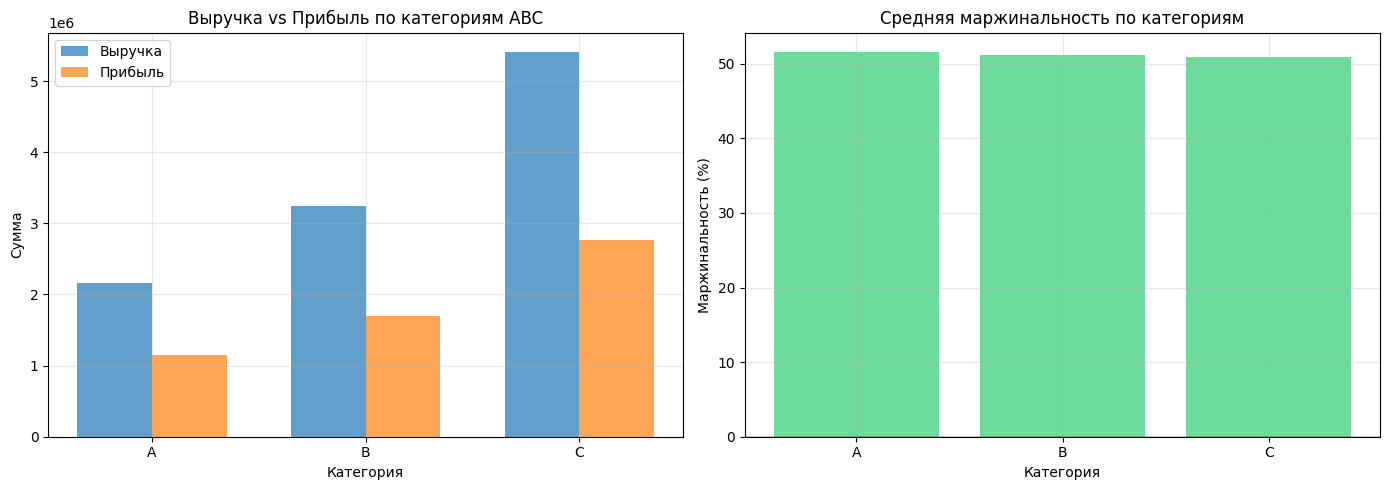

In [40]:
abc_results, abc_stats = abc_analysis(
    data_analys,
    value_column='sale_price',
    group_column='user_id',
    group_name='Клиенты',
    show_plot=False
)

# print(abc_results)

data_analys = data_analys.merge(
    abc_results[['user_id', 'category ABC']],
    on='user_id',
    how='left'
)

profit_by_category = data_analys.groupby('category ABC').agg({
    'user_id': 'count',
    'sale_price': 'sum',
    'profit': 'sum',
    'cost': 'sum',
    'margin_percent': 'mean'
}).rename(columns={'user_id': 'order_count'})

profit_by_category['profit_per_order'] = profit_by_category['profit'] / profit_by_category['order_count']
profit_by_category['revenue_per_order'] = profit_by_category['sale_price'] / profit_by_category['order_count']
profit_by_category['cost_per_order'] = profit_by_category['cost'] / profit_by_category['order_count']

print("="*60)
print("АНАЛИЗ ПРИБЫЛЬНОСТИ ПО КАТЕГОРИЯМ ABC")
print("="*60)
print(profit_by_category.round(2))

c_profit = profit_by_category.loc['C', 'profit']
if c_profit < 0:
    print("\n⚠️ КАТЕГОРИЯ C УБЫТОЧНА!")
    print(f"   Убыток: {c_profit:,.2f}")
else:
    print(f"\n✅ Категория C прибыльна: {c_profit:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(profit_by_category.index))
width = 0.35

axes[0].bar(x - width/2, profit_by_category['sale_price'], width, label='Выручка', alpha=0.7)
axes[0].bar(x + width/2, profit_by_category['profit'], width, label='Прибыль', alpha=0.7)
axes[0].set_xlabel('Категория')
axes[0].set_ylabel('Сумма')
axes[0].set_title('Выручка vs Прибыль по категориям ABC')
axes[0].set_xticks(x)
axes[0].set_xticklabels(profit_by_category.index)
axes[0].legend()
axes[0].grid(alpha=0.3)

# colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in profit_by_category['margin_percent']]
# axes[1].bar(profit_by_category.index, profit_by_category['margin_percent'], color=colors, alpha=0.7)
# axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
# axes[1].set_xlabel('Категория')
# axes[1].set_ylabel('Маржинальность (%)')
# axes[1].set_title('Средняя маржинальность по категориям')
# axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


АНАЛИЗ ЧАСТОТЫ ПОКУПОК ПО КАТЕГОРИЯМ ABC
             user_id order_count              avg_days_between_orders         \
               count        mean median   std                    mean median   
category ABC                                                                   
A               3796        2.80    3.0  1.11                  324.41  248.0   
B              10973        2.30    2.0  1.07                  355.09  257.0   
C              65252        1.37    1.0  0.66                  400.78  269.0   

             avg_order_value customer_lifetime_days  
                        mean                   mean  
category ABC                                         
A                     256.38                 527.29  
B                     162.92                 413.57  
C                      63.57                 138.94  


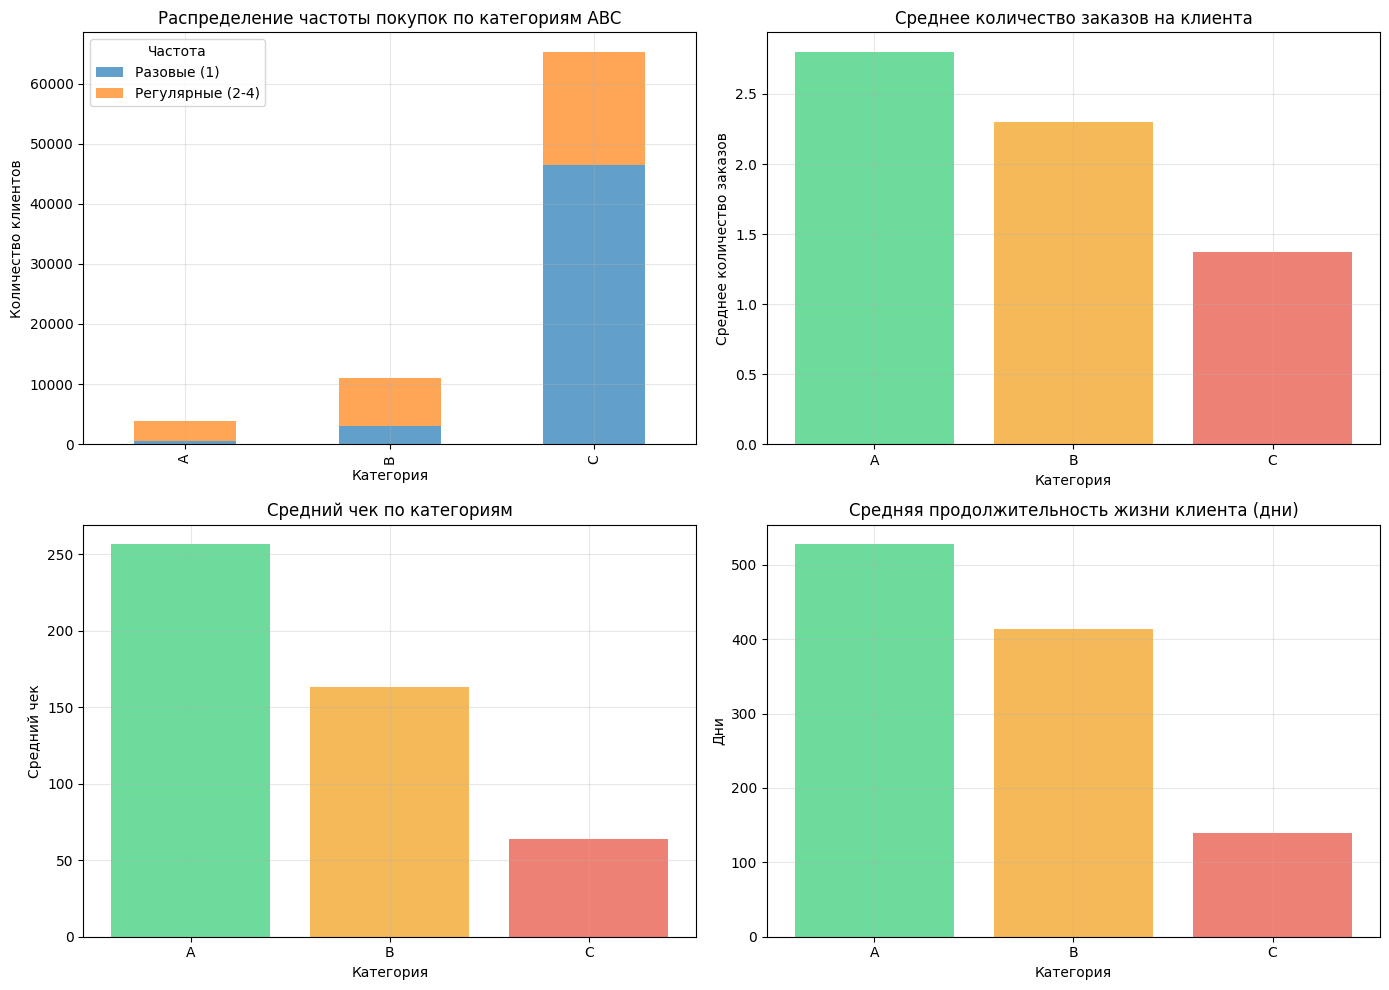

In [46]:
purchase_freq = data_analys.groupby('user_id').agg({
    'order_id': 'nunique',  # количество уникальных заказов
    'sale_price': 'sum',    # общая выручка
    'profit': 'sum',        # общая прибыль
    'created_at': ['min', 'max']  # первая и последняя покупка
}).reset_index()

purchase_freq.columns = ['user_id', 'order_count', 'total_revenue', 'total_profit', 'first_purchase', 'last_purchase']
purchase_freq['customer_lifetime_days'] = (purchase_freq['last_purchase'] - purchase_freq['first_purchase']).dt.days
purchase_freq['avg_days_between_orders'] = purchase_freq['customer_lifetime_days'] / (purchase_freq['order_count'] - 1)
purchase_freq['avg_order_value'] = purchase_freq['total_revenue'] / purchase_freq['order_count']

purchase_freq = purchase_freq.merge(abc_results[['user_id', 'category ABC']], on='user_id', how='left')

freq_by_category = purchase_freq.groupby('category ABC').agg({
    'user_id': 'count',
    'order_count': ['mean', 'median', 'std'],
    'avg_days_between_orders': ['mean', 'median'],
    'avg_order_value': 'mean',
    'customer_lifetime_days': 'mean'
}).round(2)

print("\n" + "="*60)
print("АНАЛИЗ ЧАСТОТЫ ПОКУПОК ПО КАТЕГОРИЯМ ABC")
print("="*60)
print(freq_by_category)

def classify_frequency(order_count):
    if order_count >= 10:
        return 'Очень частые (10+)'
    elif order_count >= 5:
        return 'Частые (5-9)'
    elif order_count >= 2:
        return 'Регулярные (2-4)'
    else:
        return 'Разовые (1)'

purchase_freq['frequency_category'] = purchase_freq['order_count'].apply(classify_frequency)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Распределение частоты покупок по категориям
freq_dist = pd.crosstab(purchase_freq['category ABC'], purchase_freq['frequency_category'])
freq_dist.plot(kind='bar', ax=axes[0, 0], stacked=True, alpha=0.7)
axes[0, 0].set_title('Распределение частоты покупок по категориям ABC')
axes[0, 0].set_xlabel('Категория')
axes[0, 0].set_ylabel('Количество клиентов')
axes[0, 0].legend(title='Частота')
axes[0, 0].grid(alpha=0.3)

# # График 2: Среднее количество заказов
# axes[0, 1].bar(freq_by_category.index, freq_by_category['order_count']['mean'],
#                color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7)
# axes[0, 1].set_title('Среднее количество заказов на клиента')
# axes[0, 1].set_xlabel('Категория')
# axes[0, 1].set_ylabel('Среднее количество заказов')
# axes[0, 1].grid(alpha=0.3)

# # График 3: Средний чек
# axes[1, 0].bar(freq_by_category.index, freq_by_category['avg_order_value']['mean'],
#                color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7)
# axes[1, 0].set_title('Средний чек по категориям')
# axes[1, 0].set_xlabel('Категория')
# axes[1, 0].set_ylabel('Средний чек')
# axes[1, 0].grid(alpha=0.3)

# # График 4: Lifetime клиента
# axes[1, 1].bar(freq_by_category.index, freq_by_category['customer_lifetime_days']['mean'],
#                color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7)
# axes[1, 1].set_title('Средняя продолжительность жизни клиента (дни)')
# axes[1, 1].set_xlabel('Категория')
# axes[1, 1].set_ylabel('Дни')
# axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
data_analys.columns

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item', 'product_id',
       'inventory_item_id', 'sale_price', 'first_name', 'last_name', 'email',
       'age', 'state', 'street_address', 'postal_code', 'city', 'country',
       'traffic_source', 'cost', 'category', 'brand', 'department', 'sku',
       'distribution_center_id', 'product_name', 'order_item_id',
       'delivery_longitude', 'delivery_latitude', 'warehouse_name',
       'warehouse_longitude', 'warehouse_latitude', 'is_loyal',
       'customer_review', 'year created', 'month created', 'quarter', 'profit',
       'margin_percent', 'category ABC', 'year_month'],
      dtype='object')

In [48]:
data_analys['year_month'] = data_analys['created_at'].dt.to_period('M')

/tmp/ipykernel_14267/3880944403.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data_analys['year_month'] = data_analys['created_at'].dt.to_period('M')


In [ ]:
# 1.1. Коэффициент возвратов на клиента
returns_per_user = data_analys[data_analys['returned_at'].notna()].groupby('user_id').size()
purchase_freq['return_count'] = purchase_freq['user_id'].map(returns_per_user).fillna(0)
purchase_freq['return_rate'] = purchase_freq['return_count'] / purchase_freq['order_count']

# 1.2. Recency (дней с последней покупки)
last_date = data_analys['created_at'].max()
last_purchase = data_analys.groupby('user_id')['created_at'].max()
purchase_freq['recency_days'] = (last_date - last_purchase).dt.days

# 1.3. Стабильность покупок (коэффициент вариации)
order_timing = data_analys.groupby('user_id')['created_at'].apply(
    lambda x: x.diff().dt.days.dropna().std() / x.diff().dt.days.dropna().mean() if len(x) > 1 else 0
)
purchase_freq['purchase_regularity'] = order_timing.fillna(0)

# 1.4. Доля просрочек доставки
delays = data_analys.groupby('user_id')['is_delayed'].mean()  # если добавили ранее
purchase_freq['delay_rate'] = purchase_freq['user_id'].map(delays).fillna(0)

# 1.5. Разнообразие категорий
category_diversity = data_analys.groupby('user_id')['category'].nunique()
purchase_freq['category_diversity'] = purchase_freq['user_id'].map(category_diversity).fillna(1)

# 1.6. Тренд среднего чека (рост/падение)
user_monthly_avg = data_analys.groupby(['user_id', 'month created'])['sale_price'].mean().reset_index()
user_monthly_avg['prev_avg'] = user_monthly_avg.groupby('user_id')['sale_price'].shift(1)
user_monthly_avg['trend'] = (user_monthly_avg['sale_price'] - user_monthly_avg['prev_avg']) / user_monthly_avg['prev_avg']
purchase_freq['avg_trend'] = purchase_freq['user_id'].map(user_monthly_avg.groupby('user_id')['trend'].mean()).fillna(0)

/tmp/ipykernel_14267/1857454586.py:13: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: x.diff().dt.days.dropna().std() / x.diff().dt.days.dropna().mean() if len(x) > 1 else 0


In [52]:
last_date = data_analys['created_at'].max()
print(f"Последняя дата в данных: {last_date}")

# Отток: нет покупок за последние 60 дней
cutoff_date = last_date - pd.Timedelta(days=60)
purchase_freq['churn'] = (purchase_freq['recency_days'] > 60).astype(int)

print(f"\nДоля оттока: {purchase_freq['churn'].mean():.1%}")
print(f"Клиентов с риском оттока: {purchase_freq['churn'].sum():,} из {len(purchase_freq):,}")

churn_by_abc = purchase_freq.groupby('category ABC')['churn'].agg(['mean', 'count'])
print("\nОтток по категориям ABC:")
print(churn_by_abc)

Последняя дата в данных: 2026-03-11 00:47:27+00:00

Доля оттока: 66.7%
Клиентов с риском оттока: 53,350 из 80,021

Отток по категориям ABC:
                  mean  count
category ABC                 
A             0.673867   3796
B             0.661624  10973
C             0.667137  65252


In [54]:
profit_abc = data_analys.groupby('user_id')['profit'].sum().reset_index()
profit_abc = profit_abc.sort_values('profit', ascending=False)
profit_abc['profit_cumsum'] = profit_abc['profit'].cumsum()
profit_abc['profit_percent'] = profit_abc['profit'] / profit_abc['profit'].sum() * 100
profit_abc['profit_cumpercent'] = profit_abc['profit_cumsum'] / profit_abc['profit'].sum() * 100

def classify_profit(row):
    if row['profit_cumpercent'] <= 80:
        return 'A (80% прибыли)'
    elif row['profit_cumpercent'] <= 95:
        return 'B (15% прибыли)'
    else:
        return 'C (5% прибыли)'

profit_abc['profit_category'] = profit_abc.apply(classify_profit, axis=1)


abc_comparison = purchase_freq.merge(
    profit_abc[['user_id', 'profit_category']],
    on='user_id', how='left'
)

print("📊 Распределение по прибыли:")
print(profit_abc['profit_category'].value_counts())
print(f"\nКлиенты категории A (прибыль): {len(profit_abc[profit_abc['profit_category']=='A (80% прибыли)'])}")

📊 Распределение по прибыли:
profit_category
A (80% прибыли)    35200
B (15% прибыли)    23246
C (5% прибыли)     21575
Name: count, dtype: int64

Клиенты категории A (прибыль): 35200


/tmp/ipykernel_14267/1994078368.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_user['year_month'] = monthly_user['created_at'].dt.to_period('M')


📊 Данные для XYZ-анализа: 80021 пользователей, 120760 записей
✅ Пользователей с ≥3 месяцами активности: 8907

📊 XYZ-АНАЛИЗ ПО СТАБИЛЬНОСТИ ПОКУПОК

📈 По сумме покупок (sale_price):
xyz_sales_category
Z (нестабильные)    4706
Y (средние)         3537
X (стабильные)       664
Name: count, dtype: int64

Процентное распределение:
xyz_sales_category
Z (нестабильные)    52.834849
Y (средние)         39.710340
X (стабильные)       7.454811
Name: count, dtype: float64

📦 По количеству заказов (order_id):
xyz_orders_category
X (стабильные)    8041
Y (средние)        866
Name: count, dtype: int64

Процентное распределение:
xyz_orders_category
X (стабильные)    90.27731
Y (средние)        9.72269
Name: count, dtype: float64


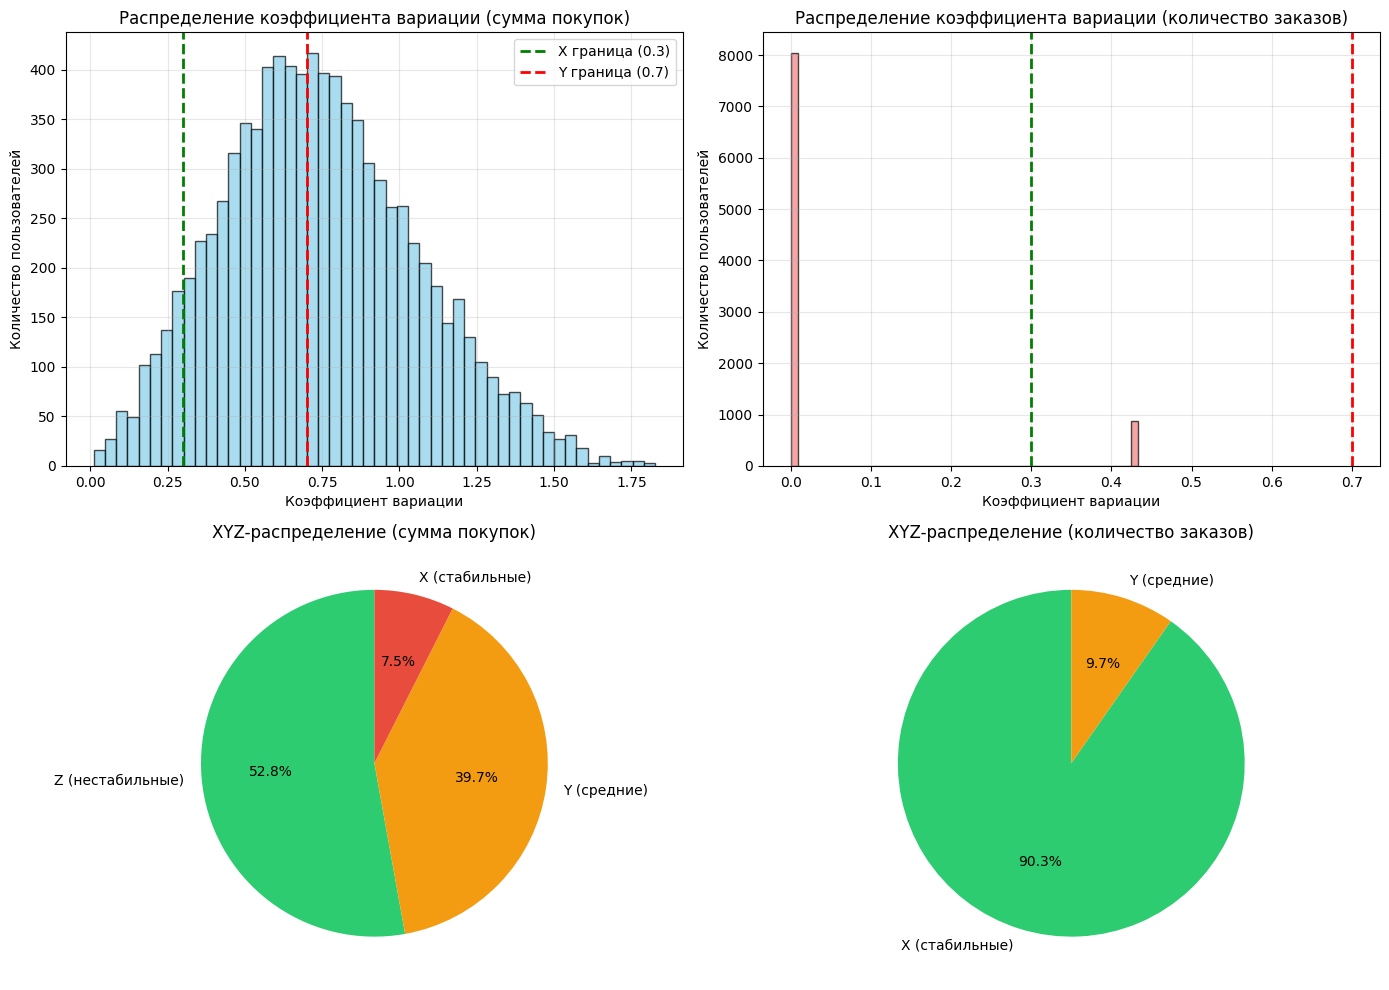


📊 Статистика по XYZ-категориям (сумма покупок):
                   avg_sales               cv_sales             user_id
                        mean median    std     mean   min   max   count
xyz_sales_category                                                     
X (стабильные)         73.36  59.07  50.12     0.21  0.01  0.30     664
Y (средние)            79.83  68.71  46.69     0.53  0.30  0.70    3537
Z (нестабильные)      100.55  88.32  56.91     0.98  0.70  1.83    4706

⚠️ Отток по XYZ-категориям:
                        mean  count
xyz_sales_category                 
X (стабильные)      0.668675    664
Y (средние)         0.666667   3537
Z (нестабильные)    0.661708   4706


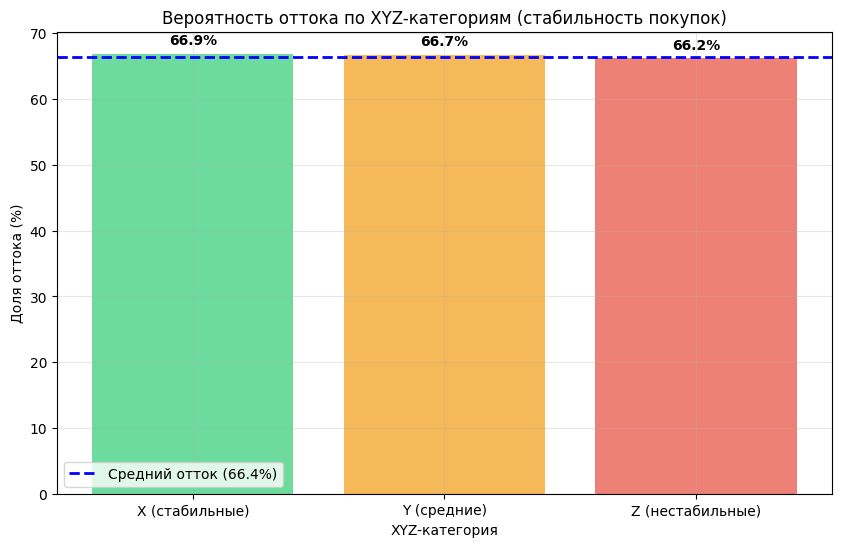


💡 Инсайт: Клиенты категории X (стабильные) оттекают на 66.9%
Клиенты категории Z (нестабильные) оттекают на 66.2%
Разница: -0.7%


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

monthly_user = data_analys.copy()
monthly_user['year_month'] = monthly_user['created_at'].dt.to_period('M')

user_monthly_sales = monthly_user.groupby(['user_id', 'year_month']).agg({
    'sale_price': 'sum',
    'order_id': 'nunique',
    'profit': 'sum'
}).reset_index()

print(f"📊 Данные для XYZ-анализа: {user_monthly_sales['user_id'].nunique()} пользователей, {len(user_monthly_sales)} записей")

# Фильтруем пользователей с минимум 3 месяцами активности
user_activity_months = user_monthly_sales.groupby('user_id').size().reset_index(name='month_count')
active_users = user_activity_months[user_activity_months['month_count'] >= 3]['user_id'].tolist()
print(f"✅ Пользователей с ≥3 месяцами активности: {len(active_users)}")

xyz_data = user_monthly_sales[user_monthly_sales['user_id'].isin(active_users)].copy()

xyz_stats = xyz_data.groupby('user_id').agg({
    'sale_price': ['mean', 'std', 'count'],
    'order_id': ['mean', 'std'],
    'profit': ['mean', 'std']
}).reset_index()

xyz_stats.columns = ['user_id', 'avg_sales', 'std_sales', 'month_count',
                     'avg_orders', 'std_orders', 'avg_profit', 'std_profit']

xyz_stats['cv_sales'] = (xyz_stats['std_sales'] / xyz_stats['avg_sales']).fillna(0)
xyz_stats['cv_orders'] = (xyz_stats['std_orders'] / xyz_stats['avg_orders']).fillna(0)

xyz_stats['cv_sales'] = xyz_stats['cv_sales'].replace([np.inf, -np.inf], 0).fillna(0)
xyz_stats['cv_orders'] = xyz_stats['cv_orders'].replace([np.inf, -np.inf], 0).fillna(0)

def classify_xyz(cv):
    if cv < 0.3:
        return 'X (стабильные)'
    elif cv < 0.7:
        return 'Y (средние)'
    else:
        return 'Z (нестабильные)'

xyz_stats['xyz_sales_category'] = xyz_stats['cv_sales'].apply(classify_xyz)
xyz_stats['xyz_orders_category'] = xyz_stats['cv_orders'].apply(classify_xyz)

print("\n" + "="*60)
print("📊 XYZ-АНАЛИЗ ПО СТАБИЛЬНОСТИ ПОКУПОК")
print("="*60)

print("\n📈 По сумме покупок (sale_price):")
sales_dist = xyz_stats['xyz_sales_category'].value_counts()
print(sales_dist)
print(f"\nПроцентное распределение:")
print(sales_dist / len(xyz_stats) * 100)

print("\n📦 По количеству заказов (order_id):")
orders_dist = xyz_stats['xyz_orders_category'].value_counts()
print(orders_dist)
print(f"\nПроцентное распределение:")
print(orders_dist / len(xyz_stats) * 100)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# axes[0, 0].hist(xyz_stats['cv_sales'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
# axes[0, 0].axvline(x=0.3, color='green', linestyle='--', linewidth=2, label='X граница (0.3)')
# axes[0, 0].axvline(x=0.7, color='red', linestyle='--', linewidth=2, label='Y граница (0.7)')
# axes[0, 0].set_title('Распределение коэффициента вариации (сумма покупок)')
# axes[0, 0].set_xlabel('Коэффициент вариации')
# axes[0, 0].set_ylabel('Количество пользователей')
# axes[0, 0].legend()
# axes[0, 0].grid(alpha=0.3)

# axes[0, 1].hist(xyz_stats['cv_orders'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
# axes[0, 1].axvline(x=0.3, color='green', linestyle='--', linewidth=2)
# axes[0, 1].axvline(x=0.7, color='red', linestyle='--', linewidth=2)
# axes[0, 1].set_title('Распределение коэффициента вариации (количество заказов)')
# axes[0, 1].set_xlabel('Коэффициент вариации')
# axes[0, 1].set_ylabel('Количество пользователей')
# axes[0, 1].grid(alpha=0.3)

# Pie chart - сумма
axes[1, 0].pie(sales_dist.values, labels=sales_dist.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
axes[1, 0].set_title('XYZ-распределение (сумма покупок)')

# Pie chart - заказы
axes[1, 1].pie(orders_dist.values, labels=orders_dist.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
axes[1, 1].set_title('XYZ-распределение (количество заказов)')

plt.tight_layout()
plt.show()

xyz_summary = xyz_stats.groupby('xyz_sales_category').agg({
    'avg_sales': ['mean', 'median', 'std'],
    'cv_sales': ['mean', 'min', 'max'],
    'user_id': 'count'
}).round(2)

print("\n📊 Статистика по XYZ-категориям (сумма покупок):")
print(xyz_summary)

xyz_with_churn = xyz_stats.merge(purchase_freq[['user_id', 'churn', 'total_revenue', 'order_count']],
                                  on='user_id', how='left')

churn_by_xyz = xyz_with_churn.groupby('xyz_sales_category')['churn'].agg(['mean', 'count'])
print("\n⚠️ Отток по XYZ-категориям:")
print(churn_by_xyz)

# # Визуализация
# fig, ax = plt.subplots(figsize=(10, 6))
# bars = ax.bar(churn_by_xyz.index, churn_by_xyz['mean'] * 100,
#               color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7)
# ax.axhline(y=xyz_with_churn['churn'].mean() * 100, color='blue', linestyle='--',
#            linewidth=2, label=f"Средний отток ({xyz_with_churn['churn'].mean()*100:.1f}%)")
# ax.set_title('Вероятность оттока по XYZ-категориям (стабильность покупок)')
# ax.set_xlabel('XYZ-категория')
# ax.set_ylabel('Доля оттока (%)')
# ax.legend()
# ax.grid(alpha=0.3)

# # Добавляем значения на столбцы
# for bar, value in zip(bars, churn_by_xyz['mean'] * 100):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
#             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

# plt.show()

print(f"\n💡 Инсайт: Клиенты категории X (стабильные) оттекают на {churn_by_xyz.loc['X (стабильные)', 'mean']*100:.1f}%")
print(f"Клиенты категории Z (нестабильные) оттекают на {churn_by_xyz.loc['Z (нестабильные)', 'mean']*100:.1f}%")
print(f"Разница: {(churn_by_xyz.loc['Z (нестабильные)', 'mean'] - churn_by_xyz.loc['X (стабильные)', 'mean'])*100:.1f}%")

Доступные колонки: ['user_id', 'order_count', 'total_revenue', 'total_profit', 'first_purchase', 'last_purchase', 'customer_lifetime_days', 'avg_days_between_orders', 'avg_order_value', 'category ABC', 'frequency_category', 'return_count', 'return_rate', 'recency_days', 'purchase_regularity', 'churn', 'xyz_sales_category']
Уникальные категории ABC: ['C' 'B' 'A']
Уникальные категории XYZ: ['Z (нестабильные)' 'Y (средние)' 'X (стабильные)']

📊 ABC-XYZ МАТРИЦА (распределение выручки)

Абсолютные значения (выручка):
xyz_sales_category  X (стабильные)  Y (средние)  Z (нестабильные)
category ABC                                                     
A                         48881.71    318945.12        1796624.41
B                         52844.42    405174.47        2788864.98
C                         55319.39    242020.89        5114433.44

Процентное распределение по строкам:
xyz_sales_category  X (стабильные)  Y (средние)  Z (нестабильные)
category ABC                                    

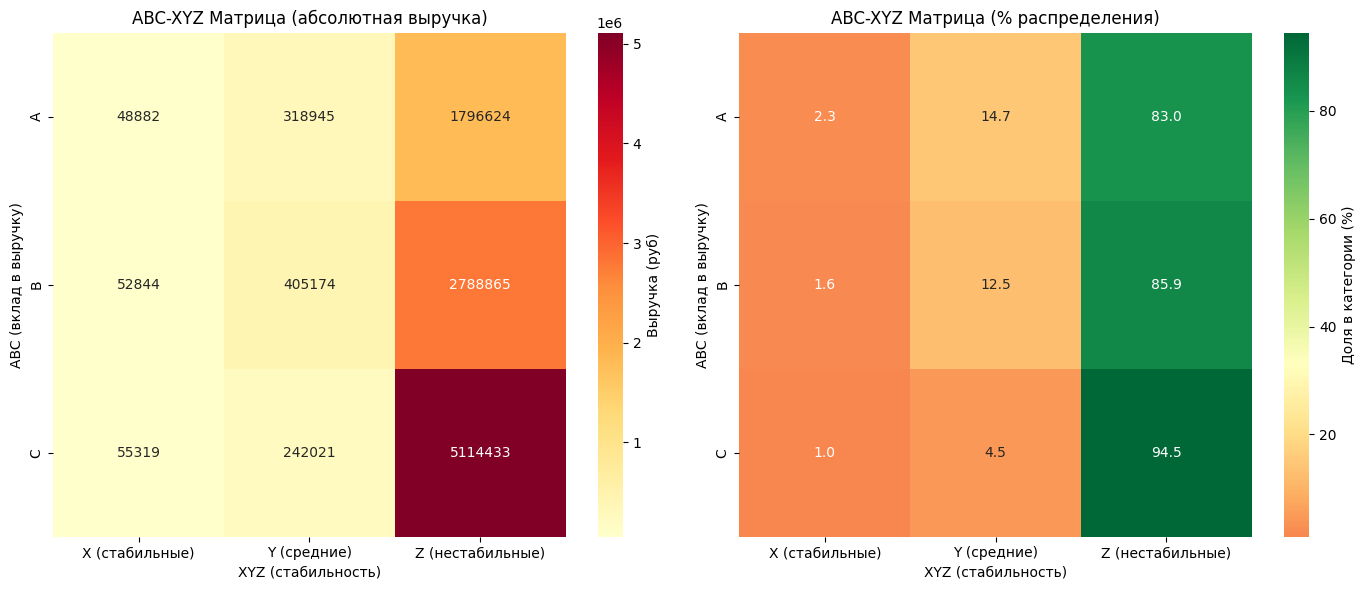


🎯 РЕКОМЕНДОВАННЫЕ СТРАТЕГИИ ПО ABC-XYZ:

A-X (стабильные): 89 клиентов, выручка: 48,882 руб
  🔒 Элитные лояльные клиенты
• VIP программа
• Персональный менеджер
• Эксклюзивные предложения

A-Y (средние): 576 клиентов, выручка: 318,945 руб
  📈 Ценные, но нестабильные
• Апсейл и кросс-продажи
• Программа лояльности
• Регулярные коммуникации

A-Z (нестабильные): 3131 клиентов, выручка: 1,796,624 руб
  ⚠️ Высокий риск потери VIP
• Срочная реактивация
• Персональные скидки
• Анализ причин нестабильности

B-X (стабильные): 181 клиентов, выручка: 52,844 руб
  📊 Надежный средний сегмент
• Увеличение среднего чека
• Кросс-продажи
• Автоматические рекомендации

B-Y (средние): 1340 клиентов, выручка: 405,174 руб
  🎯 Перспективные клиенты
• Таргетированные акции
• Email-маркетинг
• Тестирование офферов

B-Z (нестабильные): 9452 клиентов, выручка: 2,788,865 руб
  🔄 Нестабильные средние
• Анализ поведения
• Вовлекающие кампании
• Сезонные предложения

C-X (стабильные): 394 клиентов, выручка: 55,319

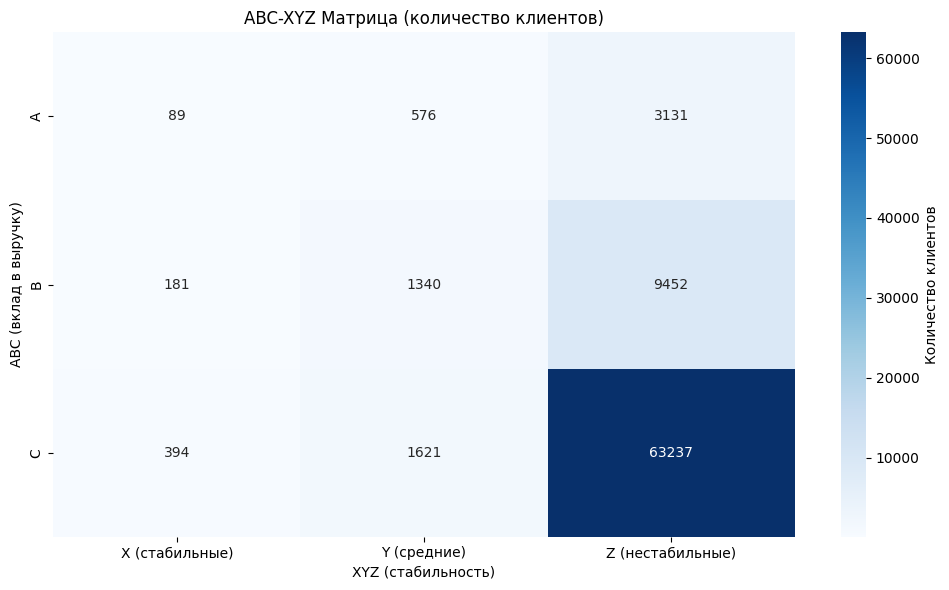

In [63]:
abc_xyz_matrix = purchase_freq.merge(xyz_stats[['user_id', 'xyz_sales_category']],
                                      on='user_id', how='left').copy()

# Заполняем пропуски для пользователей с <3 месяцев (без inplace)
abc_xyz_matrix['xyz_sales_category'] = abc_xyz_matrix['xyz_sales_category'].fillna('Z (нестабильные)')

matrix = pd.crosstab(abc_xyz_matrix['category ABC'],
                     abc_xyz_matrix['xyz_sales_category'],
                     values=abc_xyz_matrix['total_revenue'],
                     aggfunc='sum')
matrix = matrix.fillna(0)

matrix_pct = matrix.div(matrix.sum(axis=1), axis=0) * 100
matrix_pct = matrix_pct.fillna(0)  # Заполняем NaN для пустых строк

print("\n" + "="*60)
print("📊 ABC-XYZ МАТРИЦА (распределение выручки)")
print("="*60)
print("\nАбсолютные значения (выручка):")
print(matrix.round(2))

print("\nПроцентное распределение по строкам:")
print(matrix_pct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(matrix, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Выручка (руб)'})
axes[0].set_title('ABC-XYZ Матрица (абсолютная выручка)')
axes[0].set_xlabel('XYZ (стабильность)')
axes[0].set_ylabel('ABC (вклад в выручку)')

# Проценты
sns.heatmap(matrix_pct, annot=True, fmt='.1f', cmap='RdYlGn', center=33, ax=axes[1],
            cbar_kws={'label': 'Доля в категории (%)'})
axes[1].set_title('ABC-XYZ Матрица (% распределения)')
axes[1].set_xlabel('XYZ (стабильность)')
axes[1].set_ylabel('ABC (вклад в выручку)')

plt.tight_layout()
plt.show()

# 10. Стратегии для каждой ячейки ABC-XYZ
strategies = {
    ('A', 'X (стабильные)'): '🔒 Элитные лояльные клиенты\n• VIP программа\n• Персональный менеджер\n• Эксклюзивные предложения',
    ('A', 'Y (средние)'): '📈 Ценные, но нестабильные\n• Апсейл и кросс-продажи\n• Программа лояльности\n• Регулярные коммуникации',
    ('A', 'Z (нестабильные)'): '⚠️ Высокий риск потери VIP\n• Срочная реактивация\n• Персональные скидки\n• Анализ причин нестабильности',
    ('B', 'X (стабильные)'): '📊 Надежный средний сегмент\n• Увеличение среднего чека\n• Кросс-продажи\n• Автоматические рекомендации',
    ('B', 'Y (средние)'): '🎯 Перспективные клиенты\n• Таргетированные акции\n• Email-маркетинг\n• Тестирование офферов',
    ('B', 'Z (нестабильные)'): '🔄 Нестабильные средние\n• Анализ поведения\n• Вовлекающие кампании\n• Сезонные предложения',
    ('C', 'X (стабильные)'): '💎 Стабильные, но с низким чеком\n• Upsell до категории B\n• Пакетные предложения\n• Экономия ресурсов',
    ('C', 'Y (средние)'): '📧 Низкий чек, средняя стабильность\n• Email-маркетинг\n• Автоматизация\n• Минимальные инвестиции',
    ('C', 'Z (нестабильные)'): '❌ Одноразовые/хаотичные\n• Не тратить ресурсы\n• Только массовые акции\n• Анализ целесообразности'
}

# Применяем стратегии (с проверкой существования ключа)
abc_xyz_matrix['strategy_key'] = list(zip(abc_xyz_matrix['category ABC'],
                                          abc_xyz_matrix['xyz_sales_category']))

# Функция для безопасного получения стратегии
def get_strategy(key):
    return strategies.get(key, '❓ Стратегия не определена')

abc_xyz_matrix['recommended_strategy'] = abc_xyz_matrix['strategy_key'].apply(get_strategy)

# # Показываем примеры (группировка с обработкой пустых значений)
# print("\n🎯 РЕКОМЕНДОВАННЫЕ СТРАТЕГИИ ПО ABC-XYZ:")
# grouped = abc_xyz_matrix.groupby(['category ABC', 'xyz_sales_category'])

# if len(grouped) > 0:
#     for (abc, xyz), group in grouped:
#         strategy = group['recommended_strategy'].iloc[0]
#         count = len(group)
#         revenue = group['total_revenue'].sum()
#         print(f"\n{abc}-{xyz}: {count} клиентов, выручка: {revenue:,.0f} руб")
#         print(f"  {strategy}")
# else:
#     print("Нет данных для группировки")

# Дополнительный анализ: распределение клиентов по ABC-XYZ
print("\n" + "="*60)
print("📊 РАСПРЕДЕЛЕНИЕ КЛИЕНТОВ ПО ABC-XYZ")
print("="*60)

client_matrix = pd.crosstab(abc_xyz_matrix['category ABC'],
                            abc_xyz_matrix['xyz_sales_category'],
                            values=abc_xyz_matrix['user_id'],
                            aggfunc='count').fillna(0)

print("\nКоличество клиентов:")
print(client_matrix)

# Процентное распределение клиентов
client_matrix_pct = client_matrix.div(client_matrix.sum().sum(), axis=0) * 100
print("\nПроцент от всех клиентов:")
print(client_matrix_pct.round(1))

# Визуализация распределения клиентов
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(client_matrix, annot=True, fmt='.0f', cmap='Blues', ax=ax,
            cbar_kws={'label': 'Количество клиентов'})
ax.set_title('ABC-XYZ Матрица (количество клиентов)')
ax.set_xlabel('XYZ (стабильность)')
ax.set_ylabel('ABC (вклад в выручку)')
plt.tight_layout()
plt.show()


📦 XYZ-АНАЛИЗ ТОВАРОВ (стабильность спроса)
xyz_category
X (стабильные)      18720
Y (средние)          8503
Z (нестабильные)       25
Name: count, dtype: int64

Процентное распределение:
xyz_category
X (стабильные)      68.70229
Y (средние)         31.20596
Z (нестабильные)     0.09175
Name: count, dtype: float64

⚠️ Топ-10 нестабильных товаров (Z):
                                        product_name        category  \
0        Gongshow Hustle & Flow Light Jeans [SENIOR]           Jeans   
1                 American Apparel The Hampton Short          Shorts   
2                     Nike Classic Fleece Hooded Top          Active   
3        VIVILLI Lingerie Babydoll with Garter-White       Intimates   
4        Toes on the Nose Men's Pineapples Walkshort          Shorts   
5              American Essentials Men's Woven Short  Sleep & Lounge   
6               Carhartt Men's Relaxed Straight Jean           Jeans   
7                           Tallia Plain Front Pants           Pants   

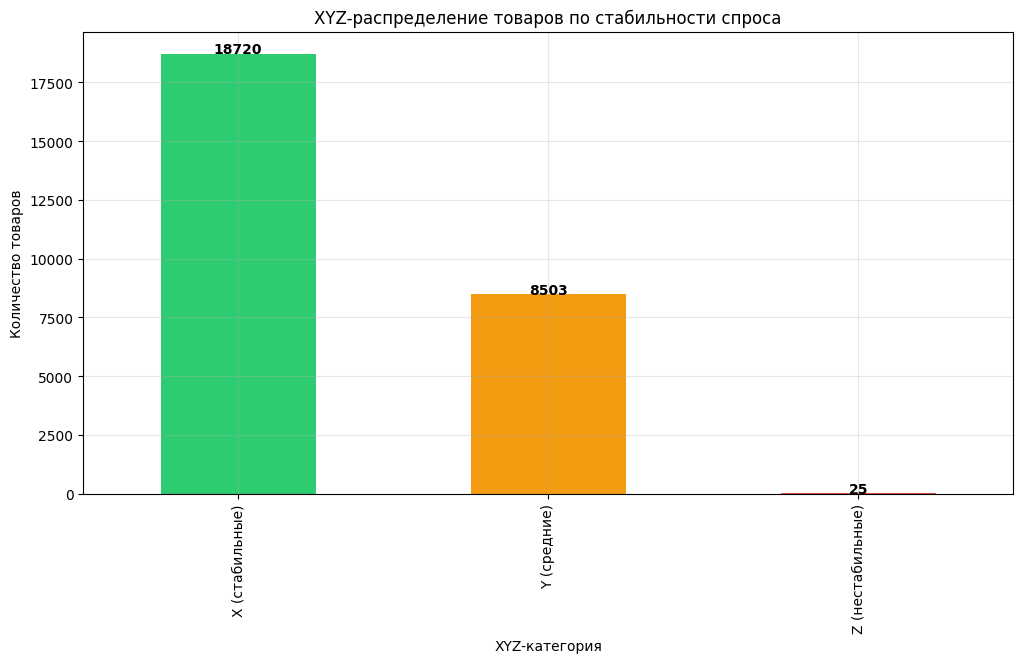

In [61]:
product_monthly = data_analys.groupby(['product_id', 'year_month'])['sale_price'].sum().reset_index()

# Фильтруем товары с минимум 3 месяцами продаж
product_months = product_monthly.groupby('product_id').size().reset_index(name='month_count')
active_products = product_months[product_months['month_count'] >= 3]['product_id'].tolist()

product_xyz = product_monthly[product_monthly['product_id'].isin(active_products)].copy()

product_stats = product_xyz.groupby('product_id').agg({
    'sale_price': ['mean', 'std', 'count']
}).reset_index()
product_stats.columns = ['product_id', 'avg_sales', 'std_sales', 'month_count']
product_stats['cv_sales'] = product_stats['std_sales'] / product_stats['avg_sales']
product_stats['cv_sales'] = product_stats['cv_sales'].replace([np.inf, -np.inf], 0).fillna(0)

product_stats['xyz_category'] = product_stats['cv_sales'].apply(classify_xyz)

print("\n" + "="*60)
print("📦 XYZ-АНАЛИЗ ТОВАРОВ (стабильность спроса)")
print("="*60)
product_dist = product_stats['xyz_category'].value_counts()
print(product_dist)
print(f"\nПроцентное распределение:")
print(product_dist / len(product_stats) * 100)

# Топ-10 нестабильных товаров (Z)
unstable_products = product_stats[product_stats['xyz_category'] == 'Z (нестабильные)']
unstable_products = unstable_products.nlargest(10, 'cv_sales')
unstable_products = unstable_products.merge(data_analys[['product_id', 'product_name', 'category']].drop_duplicates(),
                                             on='product_id')

print("\n⚠️ Топ-10 нестабильных товаров (Z):")
print(unstable_products[['product_name', 'category']])  #, 'cv_sales', 'avg_sales'

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'X (стабильные)': '#2ecc71', 'Y (средние)': '#f39c12', 'Z (нестабильные)': '#e74c3c'}
product_dist.plot(kind='bar', color=[colors[x] for x in product_dist.index], ax=ax)
ax.set_title('XYZ-распределение товаров по стабильности спроса')
ax.set_xlabel('XYZ-категория')
ax.set_ylabel('Количество товаров')
ax.grid(alpha=0.3)
for i, v in enumerate(product_dist.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

In [65]:
data_analys.shape


(181926, 44)

In [87]:
# # 12. Сводная таблица для дашборда
# xyz_dashboard = pd.DataFrame({
#     'Метрика': ['Сумма покупок (клиенты)', 'Кол-во заказов (клиенты)', 'Спрос на товары'],
#     'X (стабильные) %': [
#         len(xyz_stats[xyz_stats['xyz_sales_category'] == 'X (стабильные)']) / len(xyz_stats) * 100,
#         len(xyz_stats[xyz_stats['xyz_orders_category'] == 'X (стабильные)']) / len(xyz_stats) * 100,
#         len(product_stats[product_stats['xyz_category'] == 'X (стабильные)']) / len(product_stats) * 100
#     ],
#     'Y (средние) %': [
#         len(xyz_stats[xyz_stats['xyz_sales_category'] == 'Y (средние)']) / len(xyz_stats) * 100,
#         len(xyz_stats[xyz_stats['xyz_orders_category'] == 'Y (средние)']) / len(xyz_stats) * 100,
#         len(product_stats[product_stats['xyz_category'] == 'Y (средние)']) / len(product_stats) * 100
#     ],
#     'Z (нестабильные) %': [
#         len(xyz_stats[xyz_stats['xyz_sales_category'] == 'Z (нестабильные)']) / len(xyz_stats) * 100,
#         len(xyz_stats[xyz_stats['xyz_orders_category'] == 'Z (нестабильные)']) / len(xyz_stats) * 100,
#         len(product_stats[product_stats['xyz_category'] == 'Z (нестабильные)']) / len(product_stats) * 100
#     ]
# })

# print("\n" + "="*60)
# print("📊 СВОДНАЯ XYZ-СТАТИСТИКА")
# print("="*60)
# print(xyz_dashboard.round(1))

# # Сохраняем результаты для дашборда
# xyz_stats[['user_id', 'xyz_sales_category', 'xyz_orders_category', 'cv_sales', 'cv_orders']].to_csv('xyz_user_analysis.csv', index=False)
# product_stats[['product_id', 'xyz_category', 'cv_sales', 'avg_sales']].to_csv('xyz_product_analysis.csv', index=False)
# abc_xyz_matrix[['user_id', 'category ABC', 'xyz_sales_category', 'recommended_strategy']].to_csv('abc_xyz_matrix.csv', index=False)

# print("\n✅ Результаты XYZ-анализа сохранены в CSV файлы")


📊 СВОДНАЯ XYZ-СТАТИСТИКА
                    Метрика  X (стабильные) %  Y (средние) %  \
0   Сумма покупок (клиенты)               7.5           39.7   
1  Кол-во заказов (клиенты)              90.3            9.7   
2           Спрос на товары              68.7           31.2   

   Z (нестабильные) %  
0                52.8  
1                 0.0  
2                 0.1  

✅ Результаты XYZ-анализа сохранены в CSV файлы


In [66]:
# Список метрик для ABC/XYZ анализа на клиентах
client_metrics = {
    'total_revenue': '💰 Общая выручка',
    'total_profit': '💵 Общая прибыль',
    'order_count': '📦 Количество заказов',
    'avg_order_value': '💳 Средний чек',
    'profit_margin': '📈 Маржинальность (%)',
    'return_count': '🔄 Количество возвратов',
    'return_rate': '⚠️ Доля возвратов',
    'customer_lifetime_days': '⏱️ Lifetime (дни)',
    'category_diversity': '🎯 Разнообразие категорий',
    'brand_loyalty': '🏷️ Лояльность к брендам',
    'delivery_days_avg': '🚚 Среднее время доставки',
    'delay_rate': '⏰ Доля просрочек',
    'review_count': '✍️ Количество отзывов',
    'avg_rating_given': '⭐ Средняя оценка (кто ставит)',
    'promo_sensitivity': '🎁 Чувствительность к промо',
    'seasonality_index': '📅 Индекс сезонности'
}

product_metrics = {
    'total_revenue': '💰 Выручка по товару',
    'total_profit': '💵 Прибыль по товару',
    'quantity_sold': '📊 Количество продаж',
    'return_rate': '🔄 Доля возвратов',
    'avg_rating': '⭐ Средний рейтинг',
    'margin_percent': '📈 Маржинальность',
    'inventory_turnover': '🔄 Оборачиваемость',
    'days_in_stock': '📅 Дней в наличии',
    'basket_size': '🛒 Размер корзины (с чем покупают)',
    'repeat_purchase_rate': '🔁 Повторные покупки',
    'cross_sell_potential': '🔗 Потенциал кросс-продаж'
}

logistics_metrics = {
    'delivery_days': '🚚 Дни доставки',
    'delivery_cost': '💰 Стоимость доставки',
    'cost_per_km': '📏 Стоимость за км',
    'return_rate_by_region': '🗺️ Возвраты по регионам',
    'damage_rate': '💔 Доля повреждений',
    'warehouse_throughput': '🏭 Пропускная способность',
    'shipping_efficiency': '⚡ Эффективность отгрузки'
}

In [67]:
# ABC анализ по маржинальности клиентов
margin_abc = data_analys.groupby('user_id').agg({
    'profit': 'sum',
    'sale_price': 'sum'
}).reset_index()
margin_abc['margin_percent'] = (margin_abc['profit'] / margin_abc['sale_price'] * 100).fillna(0)

# Сортируем и классифицируем
margin_abc = margin_abc.sort_values('margin_percent', ascending=False)
margin_abc['margin_cumsum'] = margin_abc['margin_percent'].cumsum()
margin_abc['margin_cumpercent'] = margin_abc['margin_cumsum'] / margin_abc['margin_percent'].sum() * 100

def classify_margin(row):
    if row['margin_cumpercent'] <= 80:
        return 'A (высокая маржа)'
    elif row['margin_cumpercent'] <= 95:
        return 'B (средняя маржа)'
    else:
        return 'C (низкая маржа)'

margin_abc['margin_category'] = margin_abc.apply(classify_margin, axis=1)

print("📊 ABC по маржинальности:")
print(margin_abc['margin_category'].value_counts())

📊 ABC по маржинальности:
margin_category
A (высокая маржа)    61031
B (средняя маржа)    13766
C (низкая маржа)      5224
Name: count, dtype: int64


In [68]:
# XYZ анализ по стабильности возвратов
returns_xyz = data_analys.groupby(['user_id', 'year_month']).agg({
    'returned_at': lambda x: x.notna().sum()
}).reset_index()

returns_xyz.columns = ['user_id', 'year_month', 'return_count']

# Фильтруем активных клиентов
user_months = returns_xyz.groupby('user_id').size().reset_index(name='month_count')
active_users = user_months[user_months['month_count'] >= 3]['user_id']

returns_xyz_active = returns_xyz[returns_xyz['user_id'].isin(active_users)]

# Расчет CV
returns_stats = returns_xyz_active.groupby('user_id').agg({
    'return_count': ['mean', 'std']
}).reset_index()
returns_stats.columns = ['user_id', 'avg_returns', 'std_returns']
returns_stats['cv_returns'] = returns_stats['std_returns'] / returns_stats['avg_returns']
returns_stats['cv_returns'] = returns_stats['cv_returns'].replace([np.inf, -np.inf], 0).fillna(0)

def classify_xyz_returns(cv):
    if cv < 0.3:
        return 'X (стабильные возвраты)'
    elif cv < 0.7:
        return 'Y (средние)'
    else:
        return 'Z (нестабильные возвраты)'

returns_stats['returns_xyz'] = returns_stats['cv_returns'].apply(classify_xyz_returns)

print("📊 XYZ по стабильности возвратов:")
print(returns_stats['returns_xyz'].value_counts())

📊 XYZ по стабильности возвратов:
returns_xyz
X (стабильные возвраты)      6153
Z (нестабильные возвраты)    2736
Y (средние)                    18
Name: count, dtype: int64


In [69]:
# ABC анализ по убыткам от возвратов
return_loss_abc = data_analys[data_analys['returned_at'].notna()].groupby('user_id').agg({
    'sale_price': 'sum',  # Сумма возвращенных товаров
    'order_id': 'count'
}).reset_index()
return_loss_abc.columns = ['user_id', 'return_loss', 'return_count']

return_loss_abc = return_loss_abc.sort_values('return_loss', ascending=False)
return_loss_abc['loss_cumsum'] = return_loss_abc['return_loss'].cumsum()
return_loss_abc['loss_cumpercent'] = return_loss_abc['loss_cumsum'] / return_loss_abc['return_loss'].sum() * 100

def classify_return_loss(row):
    if row['loss_cumpercent'] <= 80:
        return 'A (80% убытков)'
    elif row['loss_cumpercent'] <= 95:
        return 'B (15% убытков)'
    else:
        return 'C (5% убытков)'

return_loss_abc['return_loss_category'] = return_loss_abc.apply(classify_return_loss, axis=1)

print("📊 ABC по убыткам от возвратов:")
print(return_loss_abc['return_loss_category'].value_counts())

📊 ABC по убыткам от возвратов:
return_loss_category
A (80% убытков)    5457
B (15% убытков)    3551
C (5% убытков)     2861
Name: count, dtype: int64


In [71]:
# XYZ анализ по интервалам между покупками
def calculate_purchase_intervals(user_data):
    user_data = user_data.sort_values('created_at')
    intervals = user_data['created_at'].diff().dt.days.dropna()
    return intervals.mean(), intervals.std()

intervals_data = []
for user_id, group in data_analys.groupby('user_id'):
    if len(group) >= 3:
        mean_interval, std_interval = calculate_purchase_intervals(group)
        intervals_data.append({
            'user_id': user_id,
            'mean_interval': mean_interval,
            'std_interval': std_interval,
            'purchase_count': len(group)
        })

intervals_df = pd.DataFrame(intervals_data)
intervals_df['cv_interval'] = intervals_df['std_interval'] / intervals_df['mean_interval']
intervals_df['cv_interval'] = intervals_df['cv_interval'].replace([np.inf, -np.inf], 0).fillna(0)

def classify_interval_cv(cv):
    if cv < 0.3:
        return 'X (регулярные покупки)'
    elif cv < 0.7:
        return 'Y (средняя регулярность)'
    else:
        return 'Z (хаотичные покупки)'

intervals_df['regularity_xyz'] = intervals_df['cv_interval'].apply(classify_interval_cv)

print("📊 XYZ по регулярности покупок:")
print(intervals_df['regularity_xyz'].value_counts())

# Анализ оттока
intervals_with_churn = intervals_df.merge(purchase_freq[['user_id', 'churn']], on='user_id')
churn_by_regularity = intervals_with_churn.groupby('regularity_xyz')['churn'].mean()
print("\nОтток по регулярности:")
print(churn_by_regularity)

📊 XYZ по регулярности покупок:
regularity_xyz
Z (хаотичные покупки)       18544
X (регулярные покупки)       5900
Y (средняя регулярность)      897
Name: count, dtype: int64

Отток по регулярности:
regularity_xyz
X (регулярные покупки)      0.662203
Y (средняя регулярность)    0.672241
Z (хаотичные покупки)       0.667386
Name: churn, dtype: float64


📊 ABC по регионам:
          state     sale_price       region_category
67    Guangdong  567950.540736  A (ключевые регионы)
52      England  438790.430194  A (ключевые регионы)
28   California  414493.750484  A (ключевые регионы)
190    Shanghai  273340.130246  A (ключевые регионы)
200       Texas  265682.210185  A (ключевые регионы)
197   São Paulo  243267.930223  A (ключевые регионы)
225    Zhejiang  233662.770298  A (ключевые регионы)
20      Beijing  225931.340215  A (ключевые регионы)
79        Hebei  213796.010188  A (ключевые регионы)
100     Jiangsu  195168.580278  A (ключевые регионы)


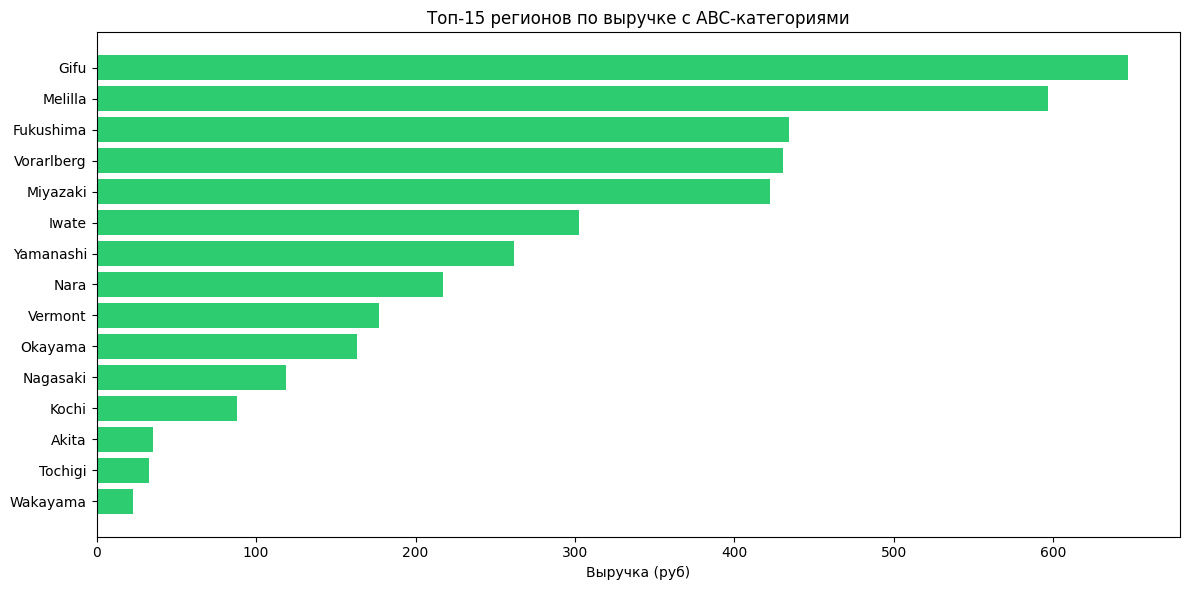

In [72]:
# ABC анализ по регионам
region_abc = data_analys.groupby('state').agg({
    'sale_price': 'sum',
    'profit': 'sum',
    'user_id': 'nunique',
    'order_id': 'count'
}).reset_index()

region_abc = region_abc.sort_values('sale_price', ascending=False)
region_abc['revenue_cumsum'] = region_abc['sale_price'].cumsum()
region_abc['revenue_cumpercent'] = region_abc['revenue_cumsum'] / region_abc['sale_price'].sum() * 100

def classify_region(row):
    if row['revenue_cumpercent'] <= 80:
        return 'A (ключевые регионы)'
    elif row['revenue_cumpercent'] <= 95:
        return 'B (развивающиеся)'
    else:
        return 'C (периферия)'

region_abc['region_category'] = region_abc.apply(classify_region, axis=1)

print("📊 ABC по регионам:")
print(region_abc[['state', 'sale_price', 'region_category']].head(10))

# Визуализация на карте (если есть координаты)
fig, ax = plt.subplots(figsize=(12, 6))
region_abc_sorted = region_abc.sort_values('sale_price', ascending=True)
colors = {'A (ключевые регионы)': '#e74c3c',
          'B (развивающиеся)': '#f39c12',
          'C (периферия)': '#2ecc71'}
bar_colors = region_abc_sorted['region_category'].map(colors)

plt.barh(region_abc_sorted['state'].head(15),
         region_abc_sorted['sale_price'].head(15),
         color=bar_colors.head(15))
plt.xlabel('Выручка (руб)')
plt.title('Топ-15 регионов по выручке с ABC-категориями')
plt.tight_layout()
plt.show()

### клиентской аналитики по  частота возвратов, сроки доставки

In [73]:
delivery_returns = data_analys.copy()


date_cols = ['created_at', 'returned_at', 'shipped_at', 'delivered_at']
for col in date_cols:
    if col in delivery_returns.columns:
        delivery_returns[col] = pd.to_datetime(delivery_returns[col], errors='coerce')


delivery_returns['delivery_days'] = (delivery_returns['delivered_at'] - delivery_returns['shipped_at']).dt.days


delivery_returns['return_days_after_delivery'] = (delivery_returns['returned_at'] - delivery_returns['delivered_at']).dt.days


delivery_returns['is_returned'] = delivery_returns['returned_at'].notna().astype(int)

print("="*60)
print("📊 АНАЛИЗ ВОЗВРАТОВ И СРОКОВ ДОСТАВКИ")
print("="*60)

print(f"\n📦 Общая статистика:")
print(f"  • Всего заказов: {delivery_returns['order_id'].nunique()}")
print(f"  • Заказов с возвратами: {delivery_returns[delivery_returns['is_returned']==1]['order_id'].nunique()}")
print(f"  • Доля возвратов: {delivery_returns['is_returned'].mean()*100:.2f}%")
print(f"  • Среднее время доставки: {delivery_returns['delivery_days'].mean():.1f} дней")
print(f"  • Среднее время до возврата: {delivery_returns[delivery_returns['is_returned']==1]['return_days_after_delivery'].mean():.1f} дней")

📊 АНАЛИЗ ВОЗВРАТОВ И СРОКОВ ДОСТАВКИ

📦 Общая статистика:
  • Всего заказов: 125085
  • Заказов с возвратами: 12498
  • Доля возвратов: 9.93%
  • Среднее время доставки: 2.0 дней
  • Медианное время доставки: 2.0 дней
  • Среднее время до возврата: 1.0 дней



📊 ABC-АНАЛИЗ: КЛИЕНТЫ ПО ЧАСТОТЕ ВОЗВРАТОВ
returns_abc_category
C (5% возвратов)     69055
A (80% возвратов)     8257
B (15% возвратов)     2709
Name: count, dtype: int64

📈 Статистика по категориям возвратов:
                     user_id return_rate return_count       
                       count        mean         mean    sum
returns_abc_category                                        
A (80% возвратов)       8257       68.47         1.75  14446
B (15% возвратов)       2709       63.92         1.00   2709
C (5% возвратов)       69055        0.84         0.01    903


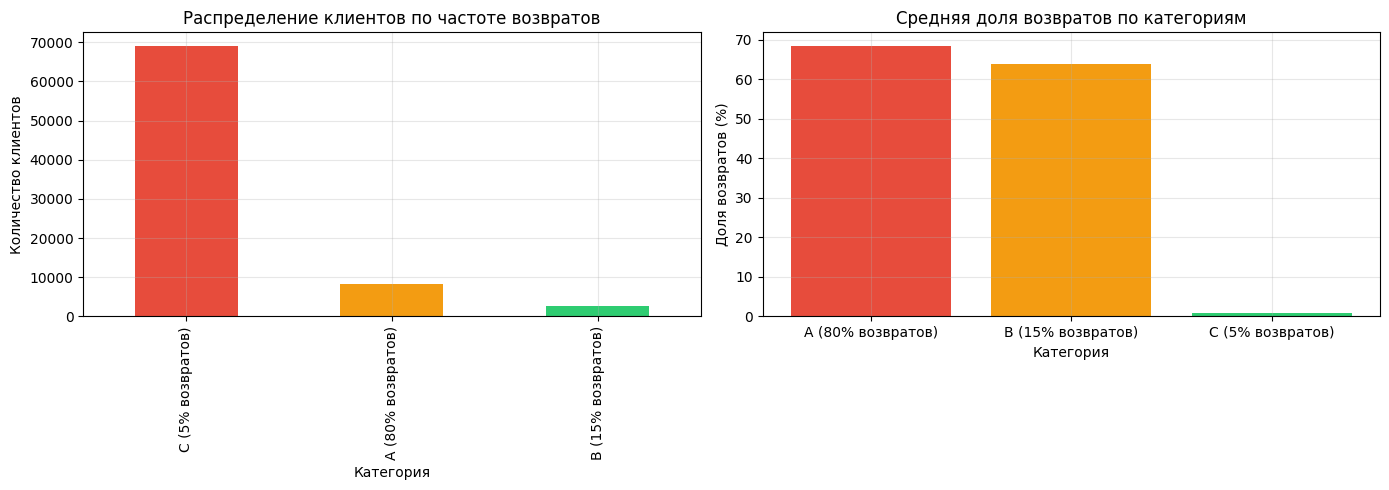

In [74]:
# returns_abc = delivery_returns.groupby('user_id').agg({
#     'order_id': 'count',  # всего заказов
#     'is_returned': 'sum',  # количество возвратов
#     'returned_at': lambda x: x.notna().sum()  # альтернативный подсчет
# }).reset_index()

# returns_abc.columns = ['user_id', 'total_orders', 'return_count', 'return_count_alt']
# returns_abc['return_rate'] = (returns_abc['return_count'] / returns_abc['total_orders'] * 100).fillna(0)

# returns_abc = returns_abc.sort_values('return_count', ascending=False)
# returns_abc['returns_cumsum'] = returns_abc['return_count'].cumsum()
# returns_abc['returns_cumpercent'] = returns_abc['returns_cumsum'] / returns_abc['return_count'].sum() * 100

# def classify_returns(row):
#     if row['returns_cumpercent'] <= 80:
#         return 'A (80% возвратов)'
#     elif row['returns_cumpercent'] <= 95:
#         return 'B (15% возвратов)'
#     else:
#         return 'C (5% возвратов)'

# returns_abc['returns_abc_category'] = returns_abc.apply(classify_returns, axis=1)

# print("\n" + "="*60)
# print("📊 ABC-АНАЛИЗ: КЛИЕНТЫ ПО ЧАСТОТЕ ВОЗВРАТОВ")
# print("="*60)
# print(returns_abc['returns_abc_category'].value_counts())

# returns_stats = returns_abc.groupby('returns_abc_category').agg({
#     'user_id': 'count',
#     'return_rate': 'mean',
#     'return_count': ['mean', 'sum']
# }).round(2)

# print("\n📈 Статистика по категориям возвратов:")
# print(returns_stats)

# # Визуализация
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Распределение категорий
# returns_abc['returns_abc_category'].value_counts().plot(kind='bar', ax=axes[0],
#                                                          color=['#e74c3c', '#f39c12', '#2ecc71'])
# axes[0].set_title('Распределение клиентов по частоте возвратов')
# axes[0].set_xlabel('Категория')
# axes[0].set_ylabel('Количество клиентов')
# axes[0].grid(alpha=0.3)

# # Доля возвратов по категориям
# avg_returns = returns_abc.groupby('returns_abc_category')['return_rate'].mean()
# axes[1].bar(avg_returns.index, avg_returns.values, color=['#e74c3c', '#f39c12', '#2ecc71'])
# axes[1].set_title('Средняя доля возвратов по категориям')
# axes[1].set_xlabel('Категория')
# axes[1].set_ylabel('Доля возвратов (%)')
# axes[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

/tmp/ipykernel_14267/3084549714.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  delivery_returns['year_month'] = delivery_returns['created_at'].dt.to_period('M')



📊 XYZ-АНАЛИЗ: СТАБИЛЬНОСТЬ ВОЗВРАТОВ
returns_xyz_category
X (стабильные возвраты)      6153
Z (нестабильные возвраты)    2736
Y (средние)                    18
Name: count, dtype: int64


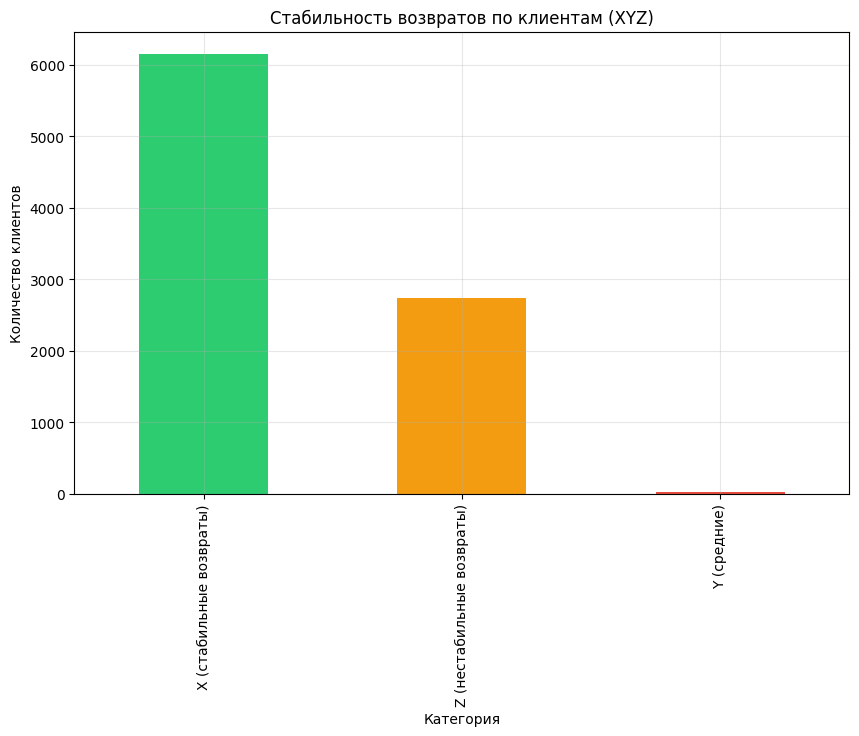

In [75]:
delivery_returns['year_month'] = delivery_returns['created_at'].dt.to_period('M')
monthly_returns = delivery_returns.groupby(['user_id', 'year_month']).agg({
    'is_returned': 'sum',
    'order_id': 'count'
}).reset_index()
monthly_returns.columns = ['user_id', 'year_month', 'return_count', 'order_count']


user_months = monthly_returns.groupby('user_id').size().reset_index(name='month_count')
active_users = user_months[user_months['month_count'] >= 3]['user_id'].tolist()
monthly_returns_active = monthly_returns[monthly_returns['user_id'].isin(active_users)]

if len(monthly_returns_active) > 0:
    # Расчет CV для возвратов
    returns_xyz = monthly_returns_active.groupby('user_id').agg({
        'return_count': ['mean', 'std']
    }).reset_index()
    returns_xyz.columns = ['user_id', 'avg_returns', 'std_returns']
    returns_xyz['cv_returns'] = returns_xyz['std_returns'] / returns_xyz['avg_returns']
    returns_xyz['cv_returns'] = returns_xyz['cv_returns'].replace([np.inf, -np.inf], 0).fillna(0)

    def classify_xyz_returns(cv):
        if cv < 0.3:
            return 'X (стабильные возвраты)'
        elif cv < 0.7:
            return 'Y (средние)'
        else:
            return 'Z (нестабильные возвраты)'

    returns_xyz['returns_xyz_category'] = returns_xyz['cv_returns'].apply(classify_xyz_returns)

    print("\n" + "="*60)
    print("📊 XYZ-АНАЛИЗ: СТАБИЛЬНОСТЬ ВОЗВРАТОВ")
    print("="*60)
    print(returns_xyz['returns_xyz_category'].value_counts())

    # Визуализация
    fig, ax = plt.subplots(figsize=(10, 6))
    returns_xyz['returns_xyz_category'].value_counts().plot(kind='bar',
                                                             color=['#2ecc71', '#f39c12', '#e74c3c'], ax=ax)
    ax.set_title('Стабильность возвратов по клиентам (XYZ)')
    ax.set_xlabel('Категория')
    ax.set_ylabel('Количество клиентов')
    ax.grid(alpha=0.3)
    plt.show()


📊 МАТРИЦА: СРОКИ ДОСТАВКИ vs ВОЗВРАТЫ
returns_category     Нет возвратов  Редкие возвраты  Частые возвраты
delivery_category                                                   
Быстрая доставка             19947              862             8781
Медленная доставка           43317                0                0
Нормальная доставка           4888              202             2024


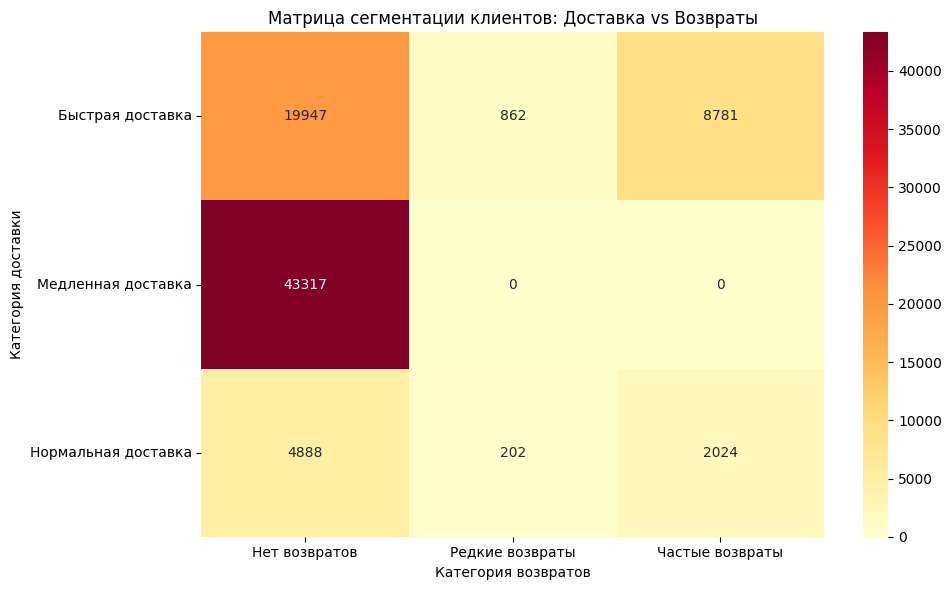

In [77]:
client_delivery_returns = delivery_returns.groupby('user_id').agg({
    'delivery_days': 'mean',
    'is_returned': 'mean',
    'order_id': 'count',
    'returned_at': lambda x: x.notna().sum()
}).reset_index()

client_delivery_returns.columns = ['user_id', 'avg_delivery_days', 'return_rate',
                                    'total_orders', 'return_count']

def classify_delivery(days):
    if days <= 3:
        return 'Быстрая доставка'
    elif days <= 7:
        return 'Нормальная доставка'
    else:
        return 'Медленная доставка'

def classify_return_rate(rate):
    if rate == 0:
        return 'Нет возвратов'
    elif rate <= 0.2:
        return 'Редкие возвраты'
    else:
        return 'Частые возвраты'

client_delivery_returns['delivery_category'] = client_delivery_returns['avg_delivery_days'].apply(classify_delivery)
client_delivery_returns['returns_category'] = client_delivery_returns['return_rate'].apply(classify_return_rate)

return_delivery_matrix = pd.crosstab(client_delivery_returns['delivery_category'],
                                      client_delivery_returns['returns_category'])

print("\n" + "="*60)
print("📊 МАТРИЦА: СРОКИ ДОСТАВКИ vs ВОЗВРАТЫ")
print("="*60)
print(return_delivery_matrix)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(return_delivery_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Матрица сегментации клиентов: Доставка vs Возвраты')
ax.set_xlabel('Категория возвратов')
ax.set_ylabel('Категория доставки')
plt.tight_layout()
plt.show()


⚠️ ВЛИЯНИЕ ВОЗВРАТОВ И ДОСТАВКИ НА ОТТОК

📊 Отток по категориям возвратов:
                      mean  count
returns_category                 
Нет возвратов     0.666539  68152
Редкие возвраты   0.643797   1064
Частые возвраты   0.669968  10805

📊 Отток по категориям доставки:
                         mean  count
delivery_category                   
Быстрая доставка     0.668807  29590
Медленная доставка   0.665559  43317
Нормальная доставка  0.664886   7114

📊 Матрица оттока (Доставка vs Возвраты):
returns_category     Нет возвратов  Редкие возвраты  Частые возвраты
delivery_category                                                   
Быстрая доставка          0.668572         0.645012         0.671677
Медленная доставка        0.665559         0.000000         0.000000
Нормальная доставка       0.666939         0.638614         0.662549


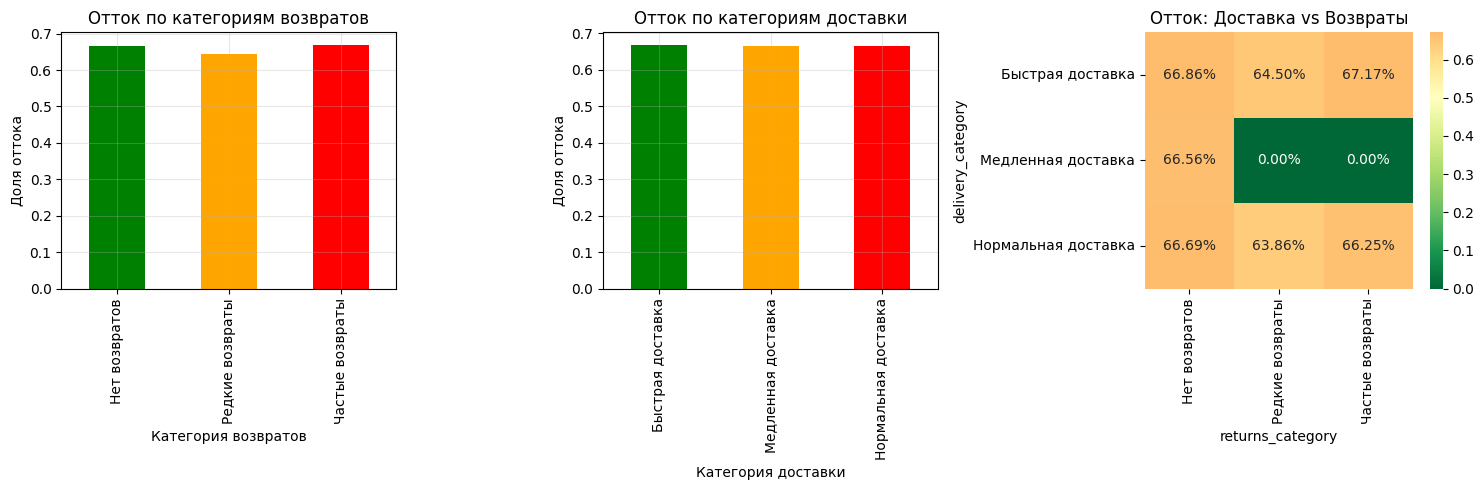


📊 Статистическая значимость:
  • Возвраты vs Отток: Chi2=3.04, p-value=0.2188
  • Доставка vs Отток: Chi2=0.95, p-value=0.6217


In [78]:
if 'churn' in purchase_freq.columns:
    client_analysis = client_delivery_returns.merge(
        purchase_freq[['user_id', 'churn', 'total_revenue']],
        on='user_id', how='left'
    )

    print("\n" + "="*60)
    print("⚠️ ВЛИЯНИЕ ВОЗВРАТОВ И ДОСТАВКИ НА ОТТОК")
    print("="*60)

    # Отток по категориям возвратов
    churn_by_returns = client_analysis.groupby('returns_category')['churn'].agg(['mean', 'count'])
    print("\n📊 Отток по категориям возвратов:")
    print(churn_by_returns)

    # Отток по категориям доставки
    churn_by_delivery = client_analysis.groupby('delivery_category')['churn'].agg(['mean', 'count'])
    print("\n📊 Отток по категориям доставки:")
    print(churn_by_delivery)

    # Комбинированный анализ
    churn_matrix = pd.crosstab(client_analysis['delivery_category'],
                               client_analysis['returns_category'],
                               values=client_analysis['churn'],
                               aggfunc='mean').fillna(0)

    print("\n📊 Матрица оттока (Доставка vs Возвраты):")
    print(churn_matrix)

    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Отток по возвратам
    churn_by_returns['mean'].plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'])
    axes[0].set_title('Отток по категориям возвратов')
    axes[0].set_xlabel('Категория возвратов')
    axes[0].set_ylabel('Доля оттока')
    axes[0].grid(alpha=0.3)

    # Отток по доставке
    churn_by_delivery['mean'].plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'])
    axes[1].set_title('Отток по категориям доставки')
    axes[1].set_xlabel('Категория доставки')
    axes[1].set_ylabel('Доля оттока')
    axes[1].grid(alpha=0.3)

    # Тепловая карта
    sns.heatmap(churn_matrix, annot=True, fmt='.2%', cmap='RdYlGn_r', center=0.5, ax=axes[2])
    axes[2].set_title('Отток: Доставка vs Возвраты')

    plt.tight_layout()
    plt.show()

    # Статистический тест
    from scipy.stats import chi2_contingency

    # Таблица сопряженности для возвратов и оттока
    contingency_returns = pd.crosstab(client_analysis['returns_category'], client_analysis['churn'])
    chi2_returns, p_returns, dof_returns, expected_returns = chi2_contingency(contingency_returns)

    # Таблица сопряженности для доставки и оттока
    contingency_delivery = pd.crosstab(client_analysis['delivery_category'], client_analysis['churn'])
    chi2_delivery, p_delivery, dof_delivery, expected_delivery = chi2_contingency(contingency_delivery)

    print("\n📊 Статистическая значимость:")
    print(f"  • Возвраты vs Отток: Chi2={chi2_returns:.2f}, p-value={p_returns:.4f}")
    print(f"  • Доставка vs Отток: Chi2={chi2_delivery:.2f}, p-value={p_delivery:.4f}")

    if p_returns < 0.05:
        print("  ✅ Связь между возвратами и оттоком статистически значима")
    if p_delivery < 0.05:
        print("  ✅ Связь между доставкой и оттоком статистически значима")

In [79]:
# 7. Выявление проблемных клиентов
client_analysis['problem_score'] = (
    client_analysis['return_rate'] * 0.6 +  # вес возвратов 60%
    (client_analysis['avg_delivery_days'] / client_analysis['avg_delivery_days'].max()) * 0.4  # вес доставки 40%
)

# Топ-20 проблемных клиентов
problem_clients = client_analysis.nlargest(20, 'problem_score')[['user_id', 'avg_delivery_days',
                                                                   'return_rate', 'return_count',
                                                                   'total_orders', 'problem_score']]

print("\n" + "="*60)
print("🚨 ТОП-20 ПРОБЛЕМНЫХ КЛИЕНТОВ (высокие возвраты + медленная доставка)")
print("="*60)
print(problem_clients.to_string(index=False))

# Рекомендации для проблемных клиентов
def get_recommendation(row):
    if row['return_rate'] > 0.3 and row['avg_delivery_days'] > 7:
        return '🔴 КРИТИЧНО: Проверить качество товаров и логистику'
    elif row['return_rate'] > 0.2:
        return '🟡 ВНИМАНИЕ: Высокая доля возвратов, проверить ассортимент'
    elif row['avg_delivery_days'] > 7:
        return '🟡 ВНИМАНИЕ: Медленная доставка, оптимизировать логистику'
    else:
        return '🟢 Нормально'

client_analysis['recommendation'] = client_analysis.apply(get_recommendation, axis=1)

print("\n💡 Рекомендации для проблемных сегментов:")
print(client_analysis['recommendation'].value_counts())


🚨 ТОП-20 ПРОБЛЕМНЫХ КЛИЕНТОВ (высокие возвраты + медленная доставка)
 user_id  avg_delivery_days  return_rate  return_count  total_orders  problem_score
      78                4.0          1.0             1             1            1.0
     154                4.0          1.0             1             1            1.0
     177                4.0          1.0             1             1            1.0
     334                4.0          1.0             1             1            1.0
     396                4.0          1.0             4             4            1.0
     665                4.0          1.0             2             2            1.0
     722                4.0          1.0             4             4            1.0
     744                4.0          1.0             1             1            1.0
     848                4.0          1.0             1             1            1.0
     921                4.0          1.0             2             2            1.0
     9

### RFM-сегментация

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

rfm_data = data_analys.copy()

current_date = rfm_data['created_at'].max()
print(f"📅 Текущая дата анализа: {current_date}")
print(f"📊 Всего уникальных клиентов: {rfm_data['user_id'].nunique()}")

rfm = rfm_data.groupby('user_id').agg({
    'created_at': lambda x: (current_date - x.max()).days,  # Recency (давность последней покупки)
    'order_id': 'nunique',  # Frequency (количество заказов)
    'sale_price': 'sum'  # Monetary (сумма всех покупок)
}).reset_index()


rfm.columns = ['user_id', 'recency', 'frequency', 'monetary']

rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

print("\n" + "="*60)
print("📊 RFM-МЕТРИКИ (основная статистика)")
print("="*60)
print(f"\nRecency (дней с последней покупки):")
print(f"  • Среднее: {rfm['recency'].mean():.1f} дней")
print(f"  • Медиана: {rfm['recency'].median():.1f} дней")
print(f"  • Минимум: {rfm['recency'].min()} дней")
print(f"  • Максимум: {rfm['recency'].max()} дней")

print(f"\nFrequency (количество заказов):")
print(f"  • Среднее: {rfm['frequency'].mean():.2f}")
print(f"  • Медиана: {rfm['frequency'].median():.0f}")
print(f"  • Максимум: {rfm['frequency'].max()}")

print(f"\nMonetary (сумма покупок):")
print(f"  • Среднее: {rfm['monetary'].mean():.0f} руб")
print(f"  • Медиана: {rfm['monetary'].median():.0f} руб")
print(f"  • Максимум: {rfm['monetary'].max():.0f} руб")

📅 Текущая дата анализа: 2026-03-11 00:47:27+00:00
📊 Всего уникальных клиентов: 80021

📊 RFM-МЕТРИКИ (основная статистика)

Recency (дней с последней покупки):
  • Среднее: 542.1 дней
  • Медиана: 362.0 дней
  • Минимум: 0 дней
  • Максимум: 2622 дней

Frequency (количество заказов):
  • Среднее: 1.56
  • Медиана: 1
  • Максимум: 4

Monetary (сумма покупок):
  • Среднее: 135 руб
  • Медиана: 90 руб
  • Максимум: 2144 руб


In [81]:
rfm['R_score'] = pd.qcut(rfm['recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop')
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4], duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop')

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("\n" + "="*60)
print("📊 РАСПРЕДЕЛЕНИЕ RFM-БАЛЛОВ")
print("="*60)
print(f"\nR_score (давность):")
print(rfm['R_score'].value_counts().sort_index())

print(f"\nF_score (частота):")
print(rfm['F_score'].value_counts().sort_index())

print(f"\nM_score (сумма):")
print(rfm['M_score'].value_counts().sort_index())

print(f"\nСуммарный RFM балл (от 3 до 12):")
print(rfm['RFM_total'].value_counts().sort_index())


📊 РАСПРЕДЕЛЕНИЕ RFM-БАЛЛОВ

R_score (давность):
R_score
1    19989
2    19988
3    20019
4    20025
Name: count, dtype: int64

F_score (частота):
F_score
1    20006
2    20005
3    20005
4    20005
Name: count, dtype: int64

M_score (сумма):
M_score
1    20007
2    20006
3    20003
4    20005
Name: count, dtype: int64

Суммарный RFM балл (от 3 до 12):
RFM_total
3      2474
4      6164
5      9821
6     11734
7     11570
8     10293
9      9142
10     8146
11     6562
12     4115
Name: count, dtype: int64



📊 RFM-СЕГМЕНТАЦИЯ КЛИЕНТОВ
segment
⚠️ At Risk (под риском)                17098
🔔 Need Attention (требуют внимания)    15595
⭐ Loyal (лояльные)                     12535
📊 Regular (обычные)                    12453
🚀 Potential (перспективные)             8019
🆕 New (новые)                           4583
👑 Champions (лучшие клиенты)            4115
💀 Lost (потерянные)                     4024
😴 About to Sleep (засыпающие)           1599
Name: count, dtype: int64

Процентное распределение:
segment
⚠️ At Risk (под риском)                21.4
🔔 Need Attention (требуют внимания)    19.5
⭐ Loyal (лояльные)                     15.7
📊 Regular (обычные)                    15.6
🚀 Potential (перспективные)            10.0
🆕 New (новые)                           5.7
👑 Champions (лучшие клиенты)            5.1
💀 Lost (потерянные)                     5.0
😴 About to Sleep (засыпающие)           2.0
Name: count, dtype: float64


/tmp/ipykernel_14267/3449533349.py:67: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/3449533349.py:67: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/3449533349.py:67: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/3449533349.py:67: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/3449533349.py:67: UserWarning: Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/3449533349.py:67: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/3449533349.py:67: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/py

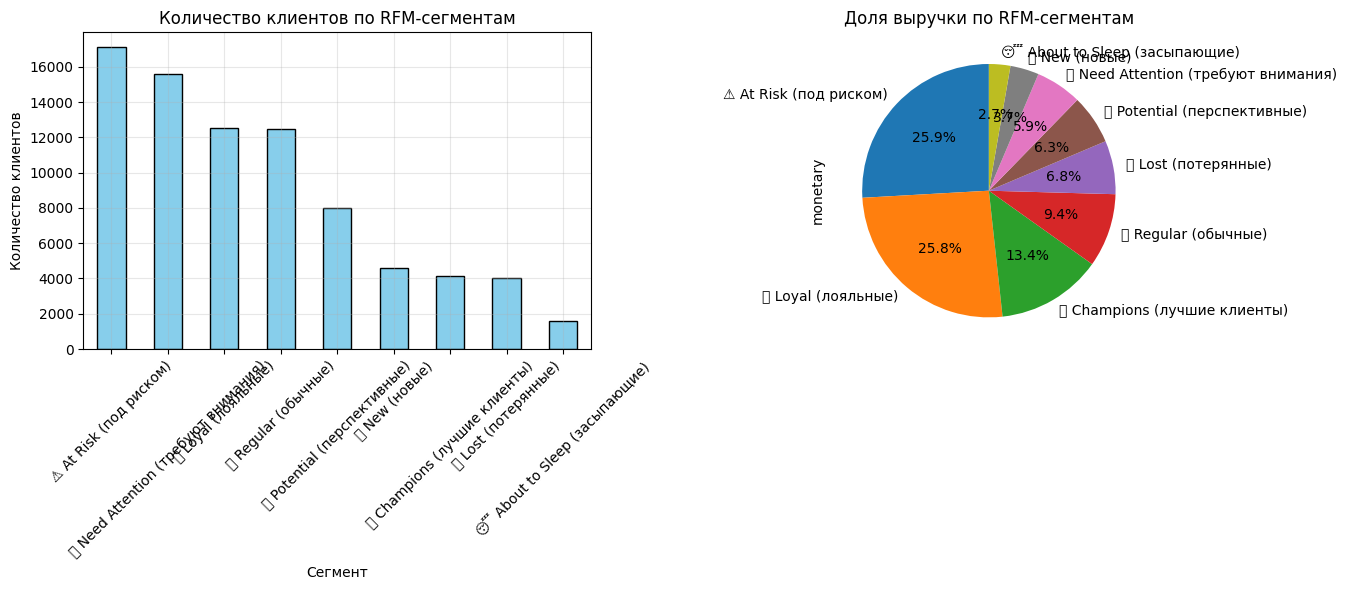

In [82]:
# 6. Классическая RFM-сегментация
def rfm_segment(row):
    # Champions: лучшие клиенты
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return '👑 Champions (лучшие клиенты)'

    # Loyal: лояльные клиенты
    elif row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return '⭐ Loyal (лояльные)'

    # Potential: перспективные
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return '🚀 Potential (перспективные)'

    # At Risk: под риском
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return '⚠️ At Risk (под риском)'

    # Need Attention: требуют внимания
    elif row['R_score'] <= 2 and row['F_score'] <= 2 and row['M_score'] <= 2:
        return '🔔 Need Attention (требуют внимания)'

    # About to Sleep: засыпающие
    elif row['R_score'] == 2 and row['F_score'] == 2:
        return '😴 About to Sleep (засыпающие)'

    # Lost: потерянные
    elif row['R_score'] == 1:
        return '💀 Lost (потерянные)'

    # New: новые клиенты
    elif row['F_score'] == 1 and row['R_score'] >= 3:
        return '🆕 New (новые)'

    else:
        return '📊 Regular (обычные)'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

print("\n" + "="*60)
print("📊 RFM-СЕГМЕНТАЦИЯ КЛИЕНТОВ")
print("="*60)
segment_counts = rfm['segment'].value_counts()
print(segment_counts)

# Процентное распределение
segment_pct = (segment_counts / len(rfm) * 100).round(1)
print("\nПроцентное распределение:")
print(segment_pct)

# Визуализация сегментов
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Количество клиентов по сегментам
segment_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Количество клиентов по RFM-сегментам')
axes[0].set_xlabel('Сегмент')
axes[0].set_ylabel('Количество клиентов')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# Доля выручки по сегментам
revenue_by_segment = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
revenue_by_segment.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Доля выручки по RFM-сегментам')

plt.tight_layout()
plt.show()


📊 ДЕТАЛЬНАЯ СТАТИСТИКА ПО RFM-СЕГМЕНТАМ
                                     Клиентов  Средний Recency (дни)  \
segment                                                                
👑 Champions (лучшие клиенты)             4115                  43.02   
⭐ Loyal (лояльные)                      12535                 155.33   
😴 About to Sleep (засыпающие)            1599                 574.83   
💀 Lost (потерянные)                      4024                1367.86   
⚠️ At Risk (под риском)                 17098                 865.89   
🆕 New (новые)                            4583                 229.42   
🚀 Potential (перспективные)              8019                  44.36   
📊 Regular (обычные)                     12453                 227.77   
🔔 Need Attention (требуют внимания)     15595                1012.28   

                                     Средняя частота  Средний Monetary (руб)  \
segment                                                                        
👑 Cham

/tmp/ipykernel_14267/2828019467.py:50: UserWarning: Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/2828019467.py:50: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/2828019467.py:50: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/2828019467.py:50: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/2828019467.py:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/2828019467.py:50: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14267/2828019467.py:50: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/py

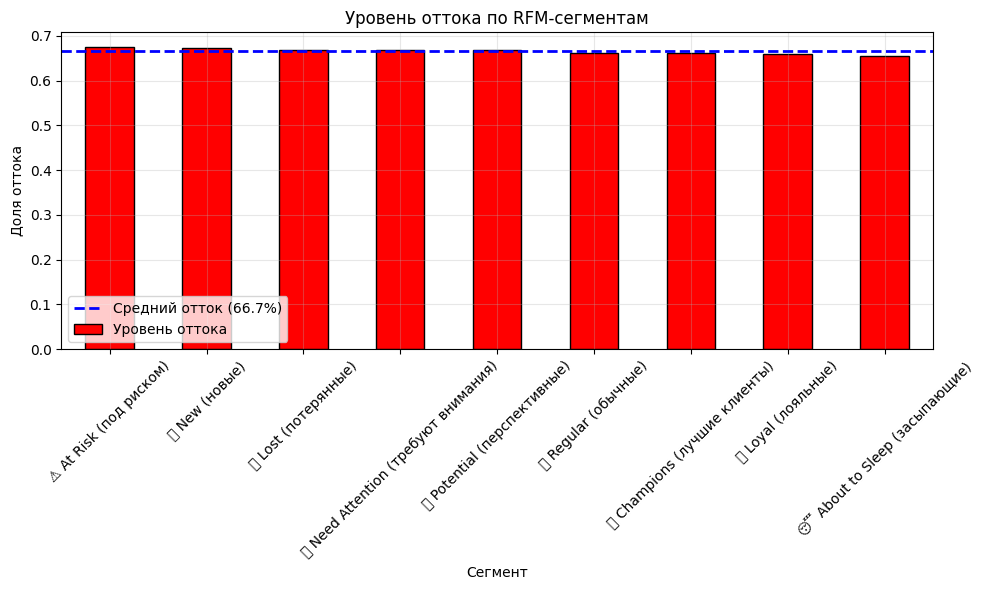

In [83]:
# 7. Детальная статистика по сегментам
segment_stats = rfm.groupby('segment').agg({
    'user_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'avg_order_value': 'mean',
    'RFM_total': 'mean'
}).round(2)

segment_stats.columns = ['Клиентов', 'Средний Recency (дни)', 'Средняя частота',
                         'Средний Monetary (руб)', 'Средний чек (руб)', 'Средний RFM балл']

# Сортируем по ценности
segment_stats = segment_stats.sort_values('Средний Monetary (руб)', ascending=False)

print("\n" + "="*60)
print("📊 ДЕТАЛЬНАЯ СТАТИСТИКА ПО RFM-СЕГМЕНТАМ")
print("="*60)
print(segment_stats)

# Сохраняем в CSV
segment_stats.to_csv('rfm_segment_statistics.csv')

# 8. Анализ оттока по сегментам (если есть данные об оттоке)
if 'churn' in purchase_freq.columns:
    rfm_with_churn = rfm.merge(purchase_freq[['user_id', 'churn']], on='user_id', how='left')
    churn_by_segment = rfm_with_churn.groupby('segment')['churn'].agg(['mean', 'count']).round(3)
    churn_by_segment.columns = ['Уровень оттока', 'Клиентов']
    churn_by_segment = churn_by_segment.sort_values('Уровень оттока', ascending=False)

    print("\n" + "="*60)
    print("⚠️ УРОВЕНЬ ОТТОКА ПО RFM-СЕГМЕНТАМ")
    print("="*60)
    print(churn_by_segment)

    # Визуализация оттока
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['red' if x > 0.5 else 'orange' if x > 0.3 else 'green'
              for x in churn_by_segment['Уровень оттока']]
    churn_by_segment['Уровень оттока'].plot(kind='bar', ax=ax, color=colors, edgecolor='black')
    ax.set_title('Уровень оттока по RFM-сегментам')
    ax.set_xlabel('Сегмент')
    ax.set_ylabel('Доля оттока')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=rfm_with_churn['churn'].mean(), color='blue', linestyle='--',
               linewidth=2, label=f"Средний отток ({rfm_with_churn['churn'].mean()*100:.1f}%)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


📊 RFM МАТРИЦА (средний Monetary по R и F)
F_score      1      2       3       4
R_score                              
1        85.90  86.31  115.38  210.78
2        88.21  86.23  131.13  227.78
3        86.38  84.40  132.56  245.16
4        84.45  86.15  139.03  251.68


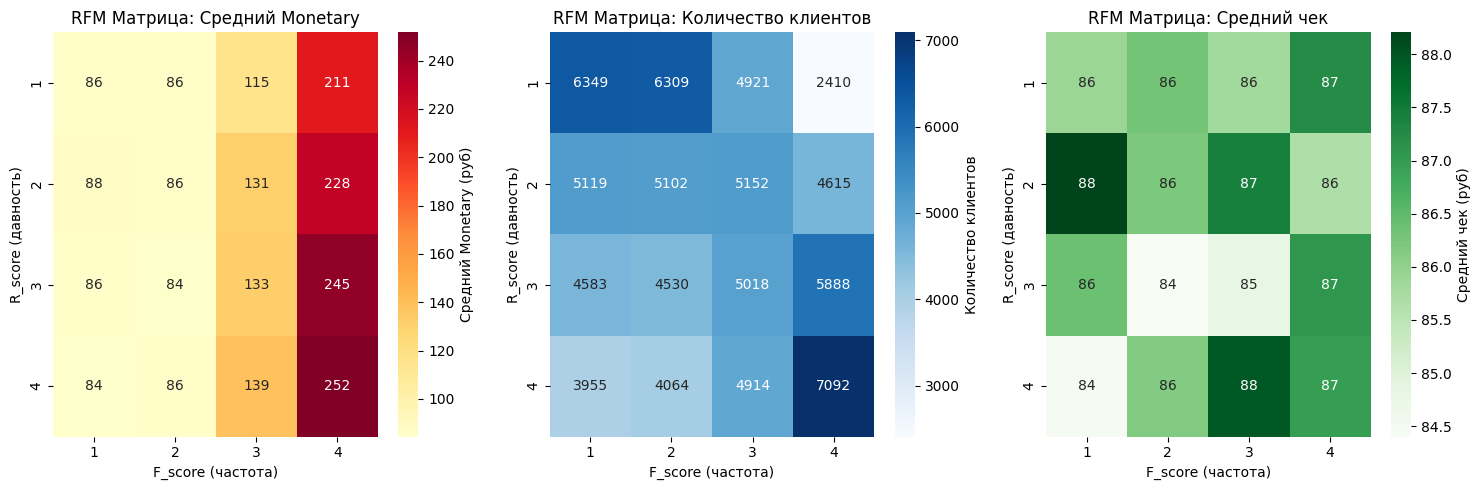

In [86]:
# 9. Создание тепловой карты RFM (матрица R и F) - ИСПРАВЛЕННАЯ ВЕРСИЯ

# Создаем матрицы без fill_value, затем заменяем NaN на 0
rfm_matrix = pd.crosstab(rfm['R_score'], rfm['F_score'],
                          values=rfm['monetary'], aggfunc='mean')
rfm_matrix = rfm_matrix.fillna(0)  # Заменяем NaN на 0

print("\n" + "="*60)
print("📊 RFM МАТРИЦА (средний Monetary по R и F)")
print("="*60)
print(rfm_matrix.round(2))

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Тепловая карта Monetary
sns.heatmap(rfm_matrix, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Средний Monetary (руб)'})
axes[0].set_title('RFM Матрица: Средний Monetary')
axes[0].set_xlabel('F_score (частота)')
axes[0].set_ylabel('R_score (давность)')

# Тепловая карта количества клиентов
rfm_count_matrix = pd.crosstab(rfm['R_score'], rfm['F_score'])
sns.heatmap(rfm_count_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            cbar_kws={'label': 'Количество клиентов'})
axes[1].set_title('RFM Матрица: Количество клиентов')
axes[1].set_xlabel('F_score (частота)')
axes[1].set_ylabel('R_score (давность)')

# Тепловая карта среднего чека
rfm_aov_matrix = pd.crosstab(rfm['R_score'], rfm['F_score'],
                              values=rfm['avg_order_value'], aggfunc='mean')
rfm_aov_matrix = rfm_aov_matrix.fillna(0)  # Заменяем NaN на 0
sns.heatmap(rfm_aov_matrix, annot=True, fmt='.0f', cmap='Greens', ax=axes[2],
            cbar_kws={'label': 'Средний чек (руб)'})
axes[2].set_title('RFM Матрица: Средний чек')
axes[2].set_xlabel('F_score (частота)')
axes[2].set_ylabel('R_score (давность)')

plt.tight_layout()
plt.show()

In [44]:
# Создаем таблицу с динамикой категорий по месяцам
# Для каждого месяца определяем категорию каждого клиента на основе их покупок в этом месяце

# Агрегируем данные по месяцам и клиентам
monthly_customer_data = data_analys.groupby(['user_id', 'year_month']).agg({
    'sale_price': 'sum',
    'order_id': 'nunique',
    'profit': 'sum'
}).reset_index()

# Функция для присвоения категории по месяцам
def assign_monthly_category(group):
    """Присваивает категорию ABC для каждого месяца отдельно"""
    if len(group) == 0:
        return group

    total_value = group['sale_price'].sum()
    group['monthly_category'] = pd.cut(
        group['sale_price'],
        bins=[-np.inf, total_value*0.5, total_value*0.8, np.inf],
        labels=['C', 'B', 'A']
    )
    return group

# Применяем для каждого месяца отдельно
monthly_categories = monthly_customer_data.groupby('year_month').apply(assign_monthly_category)

# Считаем количество клиентов в каждой категории по месяцам
monthly_distribution = monthly_categories.groupby(['year_month', 'monthly_category']).size().unstack(fill_value=0)
monthly_distribution['total_customers'] = monthly_distribution.sum(axis=1)
monthly_distribution['A_percent'] = (monthly_distribution['A'] / monthly_distribution['total_customers'] * 100).round(2)
monthly_distribution['B_percent'] = (monthly_distribution['B'] / monthly_distribution['total_customers'] * 100).round(2)
monthly_distribution['C_percent'] = (monthly_distribution['C'] / monthly_distribution['total_customers'] * 100).round(2)

print("\n" + "="*60)
print("ДИНАМИКА КАТЕГОРИЙ ПО МЕСЯЦАМ")
print("="*60)
print(monthly_distribution)

# Анализ миграции категорий (как меняется категория клиентов)
# Для каждого клиента берем первую и последнюю категорию
customer_first_last = data_analys.groupby('user_id').agg({
    'year_month': ['first', 'last'],
    'category': ['first', 'last']
}).reset_index()

customer_first_last.columns = ['user_id', 'first_month', 'last_month', 'first_category', 'last_category']

# Создаем матрицу миграции
migration_matrix = pd.crosstab(
    customer_first_last['first_category'],
    customer_first_last['last_category'],
    normalize='index'
) * 100

print("\n" + "="*60)
print("МАТРИЦА МИГРАЦИИ КАТЕГОРИЙ (%)")
print("="*60)
print(migration_matrix.round(2))

# Визуализация динамики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Динамика количества клиентов по категориям
monthly_distribution[['A', 'B', 'C']].plot(kind='line', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Динамика количества клиентов по категориям ABC')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Количество клиентов')
axes[0, 0].legend(title='Категория')
axes[0, 0].grid(alpha=0.3)

# График 2: Динамика процентов
monthly_distribution[['A_percent', 'B_percent', 'C_percent']].plot(kind='line', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Динамика доли клиентов по категориям (%)')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Процент клиентов (%)')
axes[0, 1].legend(title='Категория')
axes[0, 1].grid(alpha=0.3)

# График 3: Тепловая карта миграции
sns.heatmap(migration_matrix, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1, 0])
axes[1, 0].set_title('Матрица миграции категорий (%)')
axes[1, 0].set_xlabel('Итоговая категория')
axes[1, 0].set_ylabel('Начальная категория')

# График 4: Стабильность категорий
category_stability = customer_first_last.groupby('first_category').apply(
    lambda x: (x['first_category'] == x['last_category']).mean() * 100
).round(2)

axes[1, 1].bar(category_stability.index, category_stability.values,
               color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7)
axes[1, 1].set_title('Стабильность категорий (% остались в той же категории)')
axes[1, 1].set_xlabel('Категория')
axes[1, 1].set_ylabel('Стабильность (%)')
axes[1, 1].set_ylim(0, 100)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_14267/4200918758.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_categories = monthly_customer_data.groupby('year_month').apply(assign_monthly_category)


ValueError: 'year_month' is both an index level and a column label, which is ambiguous.


ABC-АНАЛИЗ: Категории товаров по показателю 'sale_price'
          count   total_value  value_percent  count_percent
category                                                   
A             1  1.320729e+06          12.20           3.85
B             5  4.035660e+06          37.29          19.23
C            20  5.466720e+06          50.51          76.92


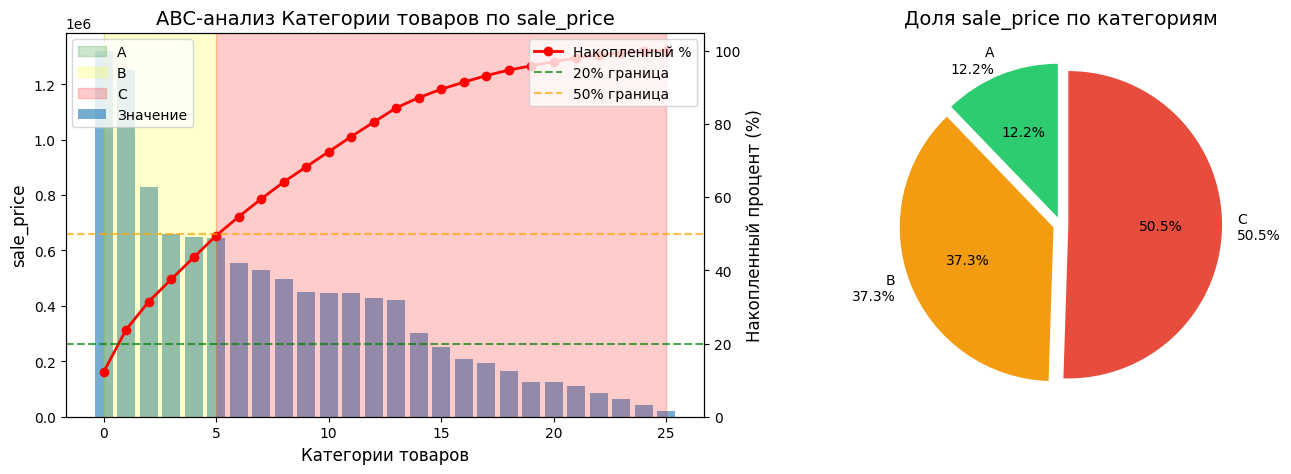

In [ ]:
# ABC-анализ категорий товаров по выручке
abc_category, category_stats = abc_analysis(
    data_clean,
    value_column='sale_price',
    group_column='category',
    group_name='Категории товаров'
)


ABC-АНАЛИЗ: Бренды по показателю 'sale_price'
          count   total_value  value_percent  count_percent
category                                                   
A            17  2.116831e+06          19.57           0.62
B            81  3.291068e+06          30.43           2.94
C          2655  5.408875e+06          50.00          96.44


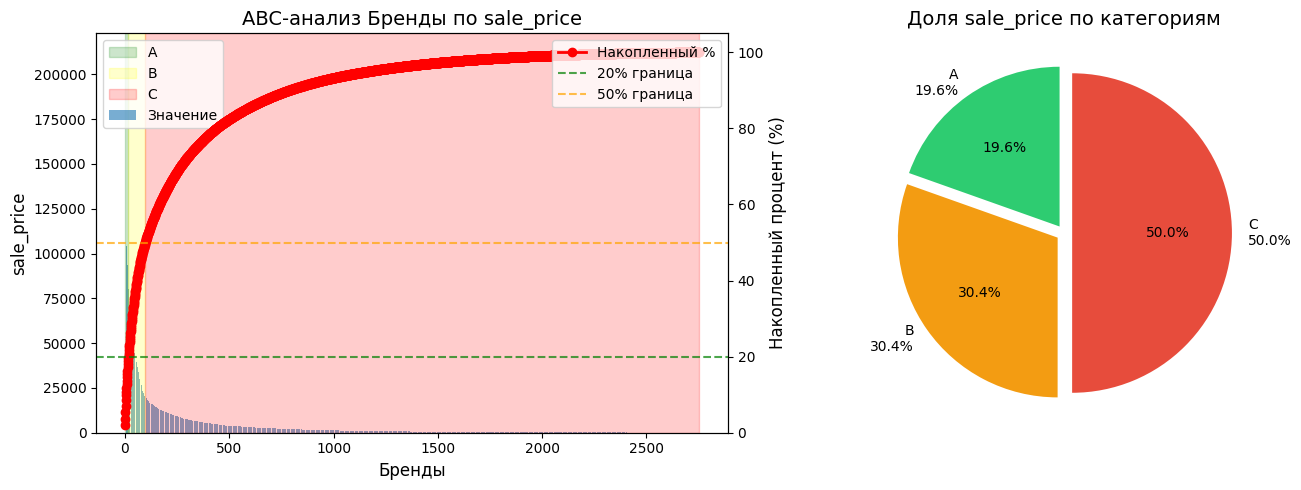

In [ ]:
# ABC-анализ брендов по выручке
abc_brand, brand_stats = abc_analysis(
    data_clean,
    value_column='sale_price',
    group_column='brand',
    group_name='Бренды'
)

In [ ]:
def detailed_category_analysis(data, abc_result, category='A'):
    """
    Детальный анализ конкретной категории
    """
    # Получаем клиентов/объекты из выбранной категории
    top_items = abc_result[abc_result['category'] == category][abc_result.columns[0]].tolist()

    # Анализируем их поведение
    filtered_data = data[data['user_id'].isin(top_items)]

    print(f"\n{'='*60}")
    print(f"ДЕТАЛЬНЫЙ АНАЛИЗ КАТЕГОРИИ {category}")
    print(f"{'='*60}")

    print(f"\nКоличество объектов: {len(top_items)}")
    print(f"Средний чек: {filtered_data['sale_price'].mean():.2f}")
    print(f"Медианный чек: {filtered_data['sale_price'].median():.2f}")
    print(f"Среднее количество товаров в заказе: {filtered_data['num_of_item'].mean():.1f}")

    # Анализ по полу
    print("\nРаспределение по полу:")
    print(filtered_data['gender'].value_counts(normalize=True) * 100)

    # Анализ по источникам трафика
    print("\nТоп-5 источников трафика:")
    print(filtered_data['traffic_source'].value_counts().head())

    return filtered_data

# Анализ каждой категории
for category in ['A', 'B', 'C']:
    detailed_category_analysis(data_clean, abc_revenue, category)


ДЕТАЛЬНЫЙ АНАЛИЗ КАТЕГОРИИ A

Количество объектов: 3796
Средний чек: 106.71
Медианный чек: 59.00
Среднее количество товаров в заказе: 2.5

Распределение по полу:
gender
M    56.086378
F    43.913622
Name: proportion, dtype: float64

Топ-5 источников трафика:
traffic_source
Search      14147
Organic      3204
Facebook     1147
Email         908
Display       877
Name: count, dtype: int64

ДЕТАЛЬНЫЙ АНАЛИЗ КАТЕГОРИИ B

Количество объектов: 10973
Средний чек: 74.12
Медианный чек: 49.99
Среднее количество товаров в заказе: 2.3

Распределение по полу:
gender
M    53.330442
F    46.669558
Name: proportion, dtype: float64

Топ-5 источников трафика:
traffic_source
Search      30779
Organic      6609
Facebook     2470
Email        2099
Display      1851
Name: count, dtype: int64

ДЕТАЛЬНЫЙ АНАЛИЗ КАТЕГОРИИ C

Количество объектов: 65252
Средний чек: 45.93
Медианный чек: 35.94
Среднее количество товаров в заказе: 1.6

Распределение по полу:
gender
F    52.019349
M    47.980651
Name: proportion, 

In [ ]:
def abc_xyz_analysis(data, value_column='sale_price',
                     group_column='user_id', time_unit='M'):
    """
    Правильный ABC-XYZ анализ

    Parameters:
    -----------
    data : DataFrame
        Исходные данные
    value_column : str
        Показатель для анализа (выручка, прибыль и т.д.)
    group_column : str
        Группировка (клиенты, категории и т.д.)
    time_unit : str
        Единица времени для агрегации:
        'D' - день, 'W' - неделя, 'M' - месяц
    """

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # 1. ABC анализ (как и раньше)
    abc_result, abc_stats = abc_analysis(
        data, value_column, group_column,
        group_name='Объекты', show_plot=False
    )

    # 2. XYZ анализ: подготовка временных рядов
    print("\n" + "="*60)
    print("XYZ АНАЛИЗ (анализ стабильности)")
    print("="*60)

    # Создаем временную колонку для агрегации
    time_col = 'created_at'

    # Определяем период для агрегации
    if time_unit == 'D':
        data['time_period'] = data[time_col].dt.date
        period_name = 'день'
    elif time_unit == 'W':
        data['time_period'] = data[time_col].dt.to_period('W').dt.start_time
        period_name = 'неделя'
    elif time_unit == 'M':
        data['time_period'] = data[time_col].dt.to_period('M').dt.start_time
        period_name = 'месяц'
    else:
        raise ValueError("time_unit должен быть 'D', 'W' или 'M'")

    # 2. Агрегируем данные по клиентам и временным периодам
    # Получаем временные ряды для каждого клиента
    time_series = data.groupby([group_column, 'time_period'])[value_column].sum().reset_index()

    # 3. Рассчитываем коэффициент вариации для каждого клиента
    # Коэффициент вариации = (стандартное отклонение / среднее) * 100%

    xyz_metrics = time_series.groupby(group_column).agg({
        value_column: ['mean', 'std', 'count']
    }).reset_index()

    xyz_metrics.columns = [group_column, 'mean_value', 'std_value', 'periods_count']

    # Коэффициент вариации в процентах
    # Защита от деления на ноль
    xyz_metrics['cv_percent'] = np.where(
        xyz_metrics['mean_value'] > 0,
        (xyz_metrics['std_value'] / xyz_metrics['mean_value']) * 100,
        0
    )

    # Заполняем NaN для клиентов с одним периодом
    xyz_metrics['cv_percent'] = xyz_metrics['cv_percent'].fillna(0)

    # 4. XYZ классификация по коэффициенту вариации
    conditions_xyz = [
        xyz_metrics['cv_percent'] <= 10,           # Стабильное потребление
        (xyz_metrics['cv_percent'] > 10) & (xyz_metrics['cv_percent'] <= 25),  # Регулярное
        xyz_metrics['cv_percent'] > 25             # Хаотическое
    ]
    choices_xyz = ['X', 'Y', 'Z']
    xyz_metrics['xyz_category'] = np.select(conditions_xyz, choices_xyz, default='Z')

    # Добавляем описание категорий
    xyz_metrics['xyz_description'] = xyz_metrics['xyz_category'].map({
        'X': 'Стабильное потребление (CV ≤ 10%)',
        'Y': 'Регулярное потребление (10% < CV ≤ 25%)',
        'Z': 'Хаотическое потребление (CV > 25%)'
    })

    # 5. Объединяем ABC и XYZ результаты
    combined = abc_result[[group_column, 'category', 'total_value']].merge(
        xyz_metrics[[group_column, 'xyz_category', 'cv_percent', 'mean_value', 'periods_count']],
        on=group_column,
        how='left'
    )

    # 6. Создаем матрицу ABC-XYZ
    matrix = pd.crosstab(
        combined['category'],
        combined['xyz_category'],
        values=combined['total_value'],
        aggfunc='sum',
        margins=True,
        margins_name='Итого'
    ).fillna(0)

    # Добавляем проценты
    total_sum = matrix.loc['Итого', 'Итого']
    matrix_percent = (matrix / total_sum * 100).round(2)

    # 7. Статистика по матрице
    print(f"\nАгрегация по {period_name}ам")
    print(f"Всего клиентов: {combined[group_column].nunique()}")
    print(f"Период анализа: {data['time_period'].min()} - {data['time_period'].max()}")
    print(f"Количество периодов: {data['time_period'].nunique()}")

    print("\n📊 МАТРИЦА ABC-XYZ (по сумме показателя):")
    print(matrix)

    print("\n📊 МАТРИЦА ABC-XYZ (в % от общего показателя):")
    print(matrix_percent)

    # 8. Статистика по XYZ категориям
    xyz_stats = combined.groupby('xyz_category').agg({
        group_column: 'count',
        'total_value': 'sum',
        'cv_percent': ['mean', 'std', 'min', 'max']
    }).round(2)

    print("\n📈 СТАТИСТИКА ПО XYZ КАТЕГОРИЯМ:")
    print(xyz_stats)

    # 9. Визуализация
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # График 1: Матрица ABC-XYZ (heatmap)
    matrix_plot = matrix.drop(index='Итого', columns='Итого')
    sns.heatmap(matrix_plot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0, 0])
    axes[0, 0].set_title('ABC-XYZ Матрица (сумма показателя)', fontsize=14)
    axes[0, 0].set_xlabel('XYZ (Стабильность)', fontsize=12)
    axes[0, 0].set_ylabel('ABC (Ценность)', fontsize=12)

    # График 2: Распределение клиентов по XYZ
    xyz_counts = combined['xyz_category'].value_counts().sort_index()
    bars = axes[0, 1].bar(xyz_counts.index, xyz_counts.values,
                          color=['#2ecc71', '#f39c12', '#e74c3c'])
    axes[0, 1].set_title('Распределение объектов по XYZ категориям', fontsize=14)
    axes[0, 1].set_xlabel('XYZ Категория', fontsize=12)
    axes[0, 1].set_ylabel('Количество объектов', fontsize=12)

    # Добавляем значения на столбцы
    for bar, count in zip(bars, xyz_counts.values):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        str(count), ha='center', fontsize=10)

    # График 3: Распределение коэффициента вариации
    axes[1, 0].hist(combined['cv_percent'], bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=10, color='green', linestyle='--', linewidth=2, label='X граница (10%)')
    axes[1, 0].axvline(x=25, color='orange', linestyle='--', linewidth=2, label='Y граница (25%)')
    axes[1, 0].set_title('Распределение коэффициента вариации', fontsize=14)
    axes[1, 0].set_xlabel('Коэффициент вариации (%)', fontsize=12)
    axes[1, 0].set_ylabel('Количество объектов', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # График 4: Временные ряды для примеров из каждой XYZ категории
    # Выбираем по одному клиенту из каждой категории для демонстрации
    axes[1, 1].set_title('Примеры временных рядов по XYZ категориям', fontsize=14)

    for cat, color in zip(['X', 'Y', 'Z'], ['#2ecc71', '#f39c12', '#e74c3c']):
        # Берем первого клиента из категории
        sample_client = combined[combined['xyz_category'] == cat][group_column].iloc[0] if len(combined[combined['xyz_category'] == cat]) > 0 else None

        if sample_client:
            client_ts = time_series[time_series[group_column] == sample_client].copy()
            client_ts = client_ts.sort_values('time_period')

            axes[1, 1].plot(client_ts['time_period'], client_ts[value_column],
                          marker='o', label=f'{cat} (CV={combined[combined[group_column]==sample_client]["cv_percent"].values[0]:.1f}%)',
                          color=color, linewidth=2, markersize=6)

    axes[1, 1].set_xlabel('Время', fontsize=12)
    axes[1, 1].set_ylabel(value_column, fontsize=12)
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # 10. Детальный анализ по комбинациям
    print("\n" + "="*60)
    print("ДЕТАЛЬНЫЙ АНАЛИЗ ПО КОМБИНАЦИЯМ ABC-XYZ")
    print("="*60)

    for abc_cat in ['A', 'B', 'C']:
        for xyz_cat in ['X', 'Y', 'Z']:
            subset = combined[(combined['category'] == abc_cat) &
                              (combined['xyz_category'] == xyz_cat)]
            if len(subset) > 0:
                print(f"\n{abc_cat}{xyz_cat}: {len(subset)} объектов")
                print(f"  Суммарный показатель: {subset['total_value'].sum():,.2f}")
                print(f"  Средний CV: {subset['cv_percent'].mean():.1f}%")
                print(f"  Среднее количество периодов: {subset['periods_count'].mean():.1f}")

    return combined, matrix, matrix_percent, xyz_metrics


ABC-АНАЛИЗ: Объекты по показателю 'sale_price'
          count   total_value  value_percent  count_percent
category                                                   
A          3796  2.164451e+06           20.0           4.74
B         10973  3.246884e+06           30.0          13.71
C         65252  5.411774e+06           50.0          81.54

XYZ АНАЛИЗ (анализ стабильности)


/tmp/ipykernel_3937/492477239.py:46: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data['time_period'] = data[time_col].dt.to_period('M').dt.start_time



Агрегация по месяцам
Всего клиентов: 80021
Период анализа: 2019-01-01 00:00:00 - 2026-03-01 00:00:00
Количество периодов: 87

📊 МАТРИЦА ABC-XYZ (по сумме показателя):
xyz_category             X              Y             Z         Итого
category                                                             
A             4.797166e+05   74079.200094  1.610655e+06  2.164451e+06
B             1.058341e+06  137857.900224  2.050685e+06  3.246884e+06
C             3.414676e+06  226813.630572  1.770284e+06  5.411774e+06
Итого         4.952733e+06  438750.730891  5.431625e+06  1.082311e+07

📊 МАТРИЦА ABC-XYZ (в % от общего показателя):
xyz_category      X     Y      Z  Итого
category                               
A              4.43  0.68  14.88   20.0
B              9.78  1.27  18.95   30.0
C             31.55  2.10  16.36   50.0
Итого         45.76  4.05  50.19  100.0

📈 СТАТИСТИКА ПО XYZ КАТЕГОРИЯМ:
             user_id total_value cv_percent                     
               count       

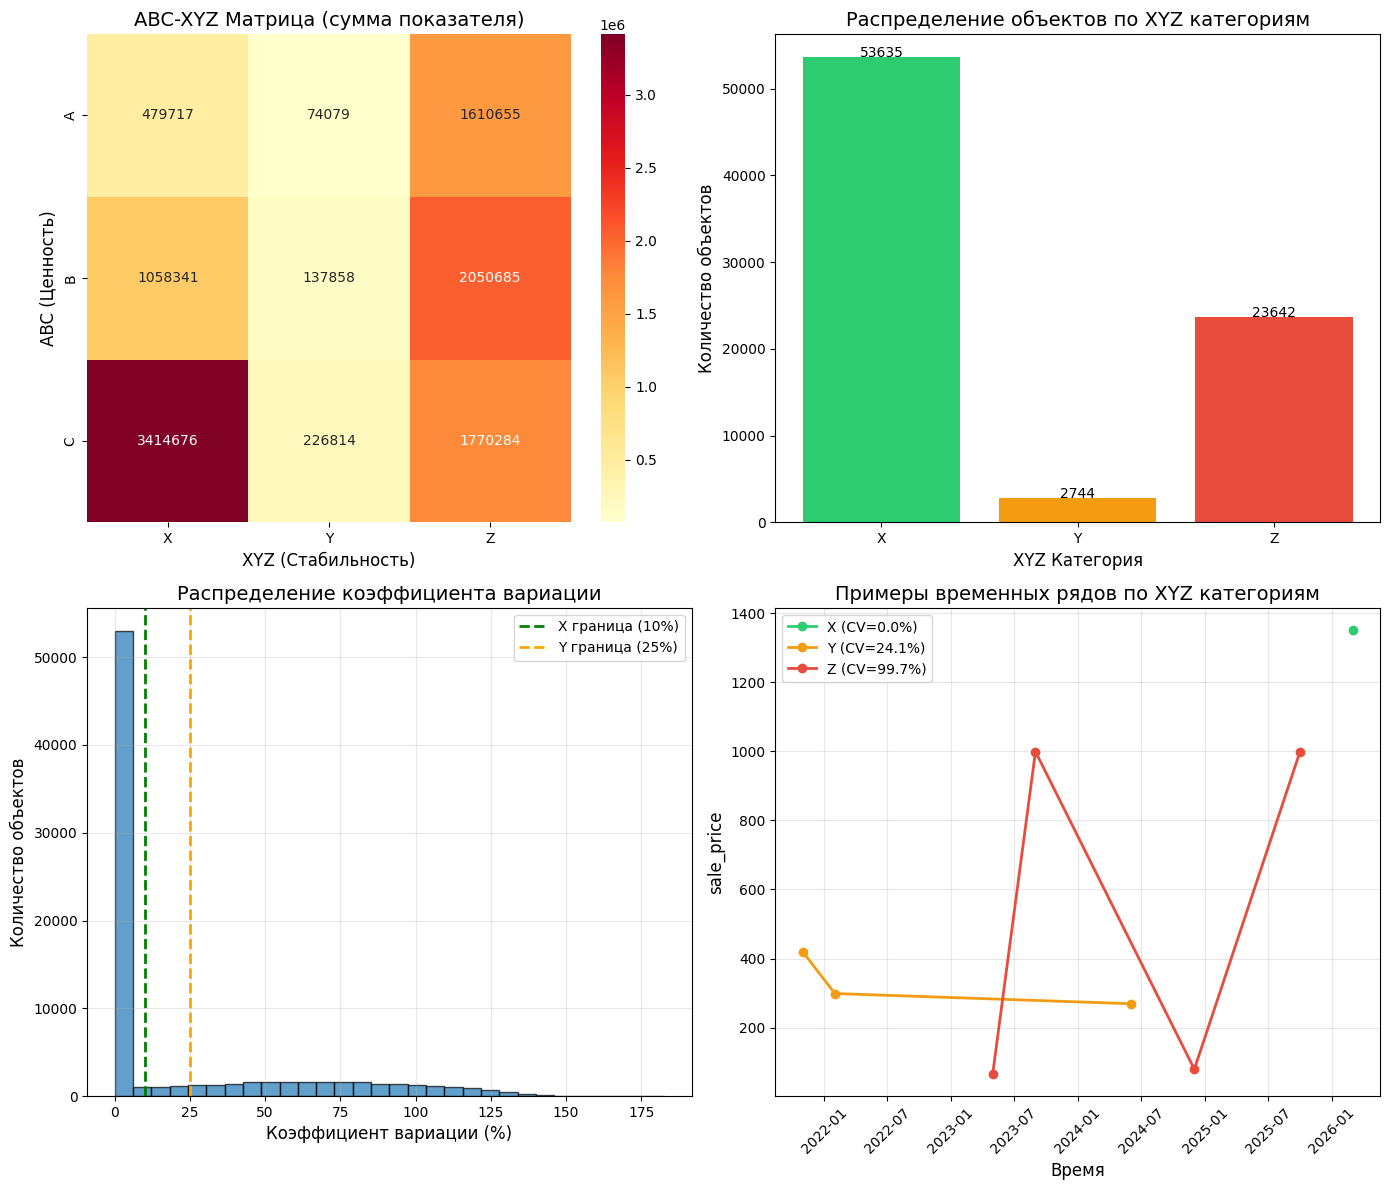


ДЕТАЛЬНЫЙ АНАЛИЗ ПО КОМБИНАЦИЯМ ABC-XYZ

AX: 836 объектов
  Суммарный показатель: 479,716.59
  Средний CV: 0.4%
  Среднее количество периодов: 1.1

AY: 141 объектов
  Суммарный показатель: 74,079.20
  Средний CV: 18.1%
  Среднее количество периодов: 2.5

AZ: 2819 объектов
  Суммарный показатель: 1,610,655.45
  Средний CV: 88.6%
  Среднее количество периодов: 3.1

BX: 3666 объектов
  Суммарный показатель: 1,058,340.77
  Средний CV: 0.4%
  Среднее количество периодов: 1.1

BY: 467 объектов
  Суммарный показатель: 137,857.90
  Средний CV: 17.8%
  Среднее количество периодов: 2.3

BZ: 6840 объектов
  Суммарный показатель: 2,050,685.20
  Средний CV: 81.0%
  Среднее количество периодов: 2.7

CX: 49133 объектов
  Суммарный показатель: 3,414,675.77
  Средний CV: 0.1%
  Среднее количество периодов: 1.0

CY: 2136 объектов
  Суммарный показатель: 226,813.63
  Средний CV: 17.7%
  Среднее количество периодов: 2.1

CZ: 13983 объектов
  Суммарный показатель: 1,770,284.31
  Средний CV: 69.5%
  Средне

In [ ]:
# Проводим корректный ABC-XYZ анализ
# time_unit параметры:
# 'D' - по дням
# 'W' - по неделям
# 'M' - по месяцам

abc_xyz_results, abc_xyz_matrix, abc_xyz_percent, xyz_metrics = abc_xyz_analysis(
    data_clean,
    value_column='sale_price',
    group_column='user_id',
    time_unit='M'  # Агрегация по месяцам
)

# Просмотр результатов XYZ анализа
print("\nТоп-10 самых стабильных клиентов (X):")
print(xyz_metrics[xyz_metrics['xyz_category'] == 'X'].head(10))

print("\nТоп-10 самых нестабильных клиентов (Z):")
print(xyz_metrics[xyz_metrics['xyz_category'] == 'Z'].head(10))


ABC-АНАЛИЗ: Объекты по показателю 'sale_price'
          count   total_value  value_percent  count_percent
category                                                   
A          3796  2.164451e+06           20.0           4.74
B         10973  3.246884e+06           30.0          13.71
C         65252  5.411774e+06           50.0          81.54

XYZ АНАЛИЗ (анализ стабильности)

Агрегация по месяцам
Всего клиентов: 80021
Период анализа: 2019-01-01 00:00:00 - 2026-03-01 00:00:00
Количество периодов: 87

📊 МАТРИЦА ABC-XYZ (по сумме показателя):
xyz_category             X              Y             Z         Итого
category                                                             
A             4.797166e+05   74079.200094  1.610655e+06  2.164451e+06
B             1.058341e+06  137857.900224  2.050685e+06  3.246884e+06
C             3.414676e+06  226813.630572  1.770284e+06  5.411774e+06
Итого         4.952733e+06  438750.730891  5.431625e+06  1.082311e+07

📊 МАТРИЦА ABC-XYZ (в % от общ

/tmp/ipykernel_3937/492477239.py:46: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data['time_period'] = data[time_col].dt.to_period('M').dt.start_time


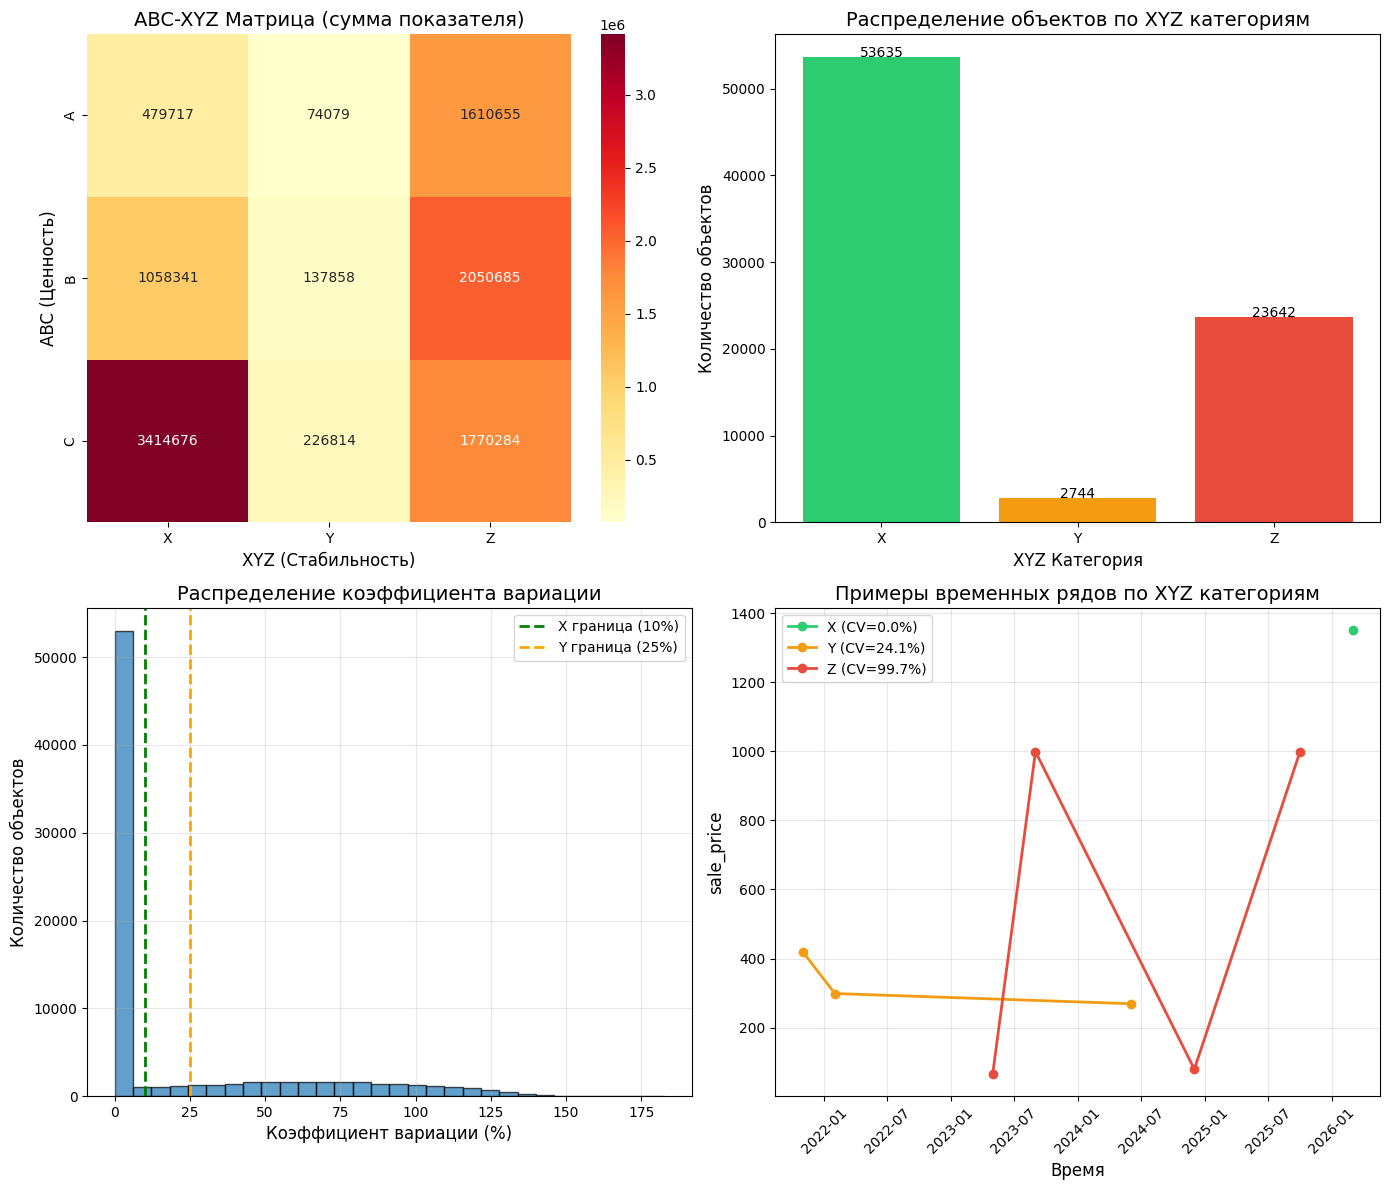


ДЕТАЛЬНЫЙ АНАЛИЗ ПО КОМБИНАЦИЯМ ABC-XYZ

AX: 836 объектов
  Суммарный показатель: 479,716.59
  Средний CV: 0.4%
  Среднее количество периодов: 1.1

AY: 141 объектов
  Суммарный показатель: 74,079.20
  Средний CV: 18.1%
  Среднее количество периодов: 2.5

AZ: 2819 объектов
  Суммарный показатель: 1,610,655.45
  Средний CV: 88.6%
  Среднее количество периодов: 3.1

BX: 3666 объектов
  Суммарный показатель: 1,058,340.77
  Средний CV: 0.4%
  Среднее количество периодов: 1.1

BY: 467 объектов
  Суммарный показатель: 137,857.90
  Средний CV: 17.8%
  Среднее количество периодов: 2.3

BZ: 6840 объектов
  Суммарный показатель: 2,050,685.20
  Средний CV: 81.0%
  Среднее количество периодов: 2.7

CX: 49133 объектов
  Суммарный показатель: 3,414,675.77
  Средний CV: 0.1%
  Среднее количество периодов: 1.0

CY: 2136 объектов
  Суммарный показатель: 226,813.63
  Средний CV: 17.7%
  Среднее количество периодов: 2.1

CZ: 13983 объектов
  Суммарный показатель: 1,770,284.31
  Средний CV: 69.5%
  Средне

ValueError: too many values to unpack (expected 2)

In [ ]:
# Проводим ABC-XYZ анализ
abc_xyz_results, abc_xyz_matrix = abc_xyz_analysis(data_clean, 'sale_price', 'user_id')

# EVENT.CSV

### Посмотрим на данные

In [ ]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/events.csv'



Mounted at /content/drive


In [ ]:
events = pd.read_csv(file_path)

In [ ]:
events

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1840721,NaN,3,32c825f3-2e85-4f79-ad2b-188d3ae22785,2022-12-27 02:05:00+00:00,153.11.214.106,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
1,1677966,NaN,3,1e21f050-a916-4863-94a0-2a4e474d60c2,2024-06-30 16:04:00+00:00,62.51.52.204,São Paulo,São Paulo,02675-031,Firefox,Adwords,/cancel,cancel
2,1440516,NaN,3,239ccdcb-c9b8-4cab-8203-ef7c4215526f,2024-02-19 07:16:00+00:00,91.225.208.255,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
3,1967607,NaN,3,b9082731-7773-4371-b03c-c93d702d7feb,2020-07-17 14:39:00+00:00,90.150.5.159,Aomori City,Aomori,038-0042,Other,Adwords,/cancel,cancel
4,2068472,NaN,3,73feafb9-135d-47eb-8b82-dc73342edf81,2024-09-29 07:56:00+00:00,151.108.206.70,Huanggang,Beijing,100010,Firefox,Adwords,/cancel,cancel
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865319,957931,73130.0,7,8ee43770-d0a2-47b6-9c40-6397ece27683,2025-12-22 15:00:15+00:00,123.5.134.160,Northolt,England,UB5,Chrome,Email,/purchase,purchase
4865320,179507,13521.0,7,3ae1b740-54a5-497a-88e8-060aabd2f098,2023-08-28 14:13:05+00:00,126.144.194.193,London,England,W9,IE,Adwords,/purchase,purchase
4865321,393641,30019.0,7,097eae72-f037-42a9-9ab5-b229ad630f10,2025-11-05 00:02:22+00:00,58.245.136.0,Dewsbury,England,WF12,Chrome,Email,/purchase,purchase
4865322,220770,16714.0,10,beaf1322-c5b3-4175-b93f-f0445d27d8aa,2025-10-31 22:52:25+00:00,169.98.203.100,Scarborough,England,YO12,Firefox,Facebook,/purchase,purchase


In [ ]:
events.shape

In [ ]:
events.info()

### Удалим дубликаты

In [ ]:
events.duplicated().sum()

In [ ]:
events[events.duplicated(keep= False)].sort_values(by=list(events.columns)).head(5)

In [ ]:
events1 = events.drop_duplicates()
# оставит первое вхождение

In [ ]:
events1.shape

### Работа с null

In [ ]:
events1.isnull().sum()[events1.isnull().sum() > 0]



In [ ]:
events1[events1['user_id'].isna()][['user_id', 'ip_address']]

In [ ]:
# Находим все ip_address, у которых есть null user_id
null_ips = events1[events1['user_id'].isna()]['ip_address'].unique()

# Выводим строки с not null user_id, у которых ip_address входит в этот список
events1[events1['user_id'].notna() & events1['ip_address'].isin(null_ips)][['user_id', 'ip_address']]

In [ ]:
# Создаем словарь: ip -> user_id
ip_to_user = events1[events1['user_id'].notna()].set_index('ip_address')['user_id'].to_dict()

# Заполняем пропуски
events1['user_id'] = events1['user_id'].fillna(events1['ip_address'].map(ip_to_user))

In [ ]:
events1[['user_id', 'ip_address']][events1['ip_address'] == '214.247.107.215']

In [ ]:
events1[events1['user_id'].isna()][['user_id', 'ip_address']]

In [ ]:
events1[['user_id', 'ip_address']][events1['ip_address'] == '91.225.208.255']

In [ ]:
events1[events1['city'].isna()][['city', 'ip_address']]

In [ ]:
# Находим все ip_address, у которых есть null user_id
null_ips1 = events1[events1['city'].isna()]['ip_address'].unique()

# Выводим строки с not null user_id, у которых ip_address входит в этот список
events1[events1['city'].notna() & events1['ip_address'].isin(null_ips1)][['city', 'ip_address']]

In [ ]:
# Создаем словарь: ip -> user_id
ip_to_city = events1[events1['city'].notna()].set_index('ip_address')['city'].to_dict()

# Заполняем пропуски
events1['city'] = events1['city'].fillna(events1['ip_address'].map(ip_to_city))

In [ ]:
events1.isnull().sum()[events1.isnull().sum() > 0]